# Telecom Customer, Revenue, and Operations Analysis

This notebook analyzes a synthetic telecom dataset to answer business questions related to customer growth, revenue, churn, acquisition performance, customer behavior, and operational efficiency.

The analysis uses SQLite for SQL-based analysis, Python for additional analysis, and visualizations that will help inform the accompanying Tableau dashboard.

In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import sqlite3
from pathlib import Path
import plotly.express as px

## Loading Generated Data

The generated CSV files are loaded into pandas DataFrames for analysis and then loaded into a SQLite database for SQL-based analysis.

In [2]:
data_path = Path("data")

In [3]:
customers = pd.read_csv(
    data_path/"customers.csv"
)

plans = pd.read_csv(
    data_path/"plans.csv" 
)

subscriptions = pd.read_csv(
    data_path/"subscriptions.csv"
)

acquisitions = pd.read_csv(
    data_path/"acquisitions.csv"
)

monthly_usage = pd.read_csv(
    data_path/"monthly_usage.csv"
)

support_tickets = pd.read_csv(
    data_path/"support_tickets.csv"
)

monthly_billing = pd.read_csv(
    data_path/"monthly_billing.csv"
)

customer_churn = pd.read_csv(
    data_path/"customer_churn.csv"
)

network_events = pd.read_csv(
    data_path/"network_events.csv"
)

In [4]:
# Restoring date columns
customers["signup_date"] = pd.to_datetime(
    customers["signup_date"]
)

customers["date_of_birth"] = pd.to_datetime(
    customers["date_of_birth"]
)

subscriptions["start_date"] = pd.to_datetime(
    subscriptions["start_date"]
)

subscriptions["end_date"] = pd.to_datetime(
    subscriptions["end_date"]
)

acquisitions["acquisition_date"] = pd.to_datetime(
    acquisitions["acquisition_date"]
)

monthly_usage["usage_month"] = pd.to_datetime(
    monthly_usage["usage_month"]
)

support_tickets["ticket_date"] = pd.to_datetime(
    support_tickets["ticket_date"]
)

monthly_billing["billing_month"] = pd.to_datetime(
    monthly_billing["billing_month"]
)

customer_churn["churn_date"] = pd.to_datetime(
    customer_churn["churn_date"]
)

network_events["event_month"] = pd.to_datetime(
    network_events["event_month"]
)

In [5]:
# Checking conversion worked
print(customers.dtypes)
print(subscriptions.dtypes)
print(acquisitions.dtypes)
print(monthly_usage.dtypes)
print(support_tickets.dtypes)
print(monthly_billing.dtypes)
print(customer_churn.dtypes)
print(network_events.dtypes)

customer_id                    object
signup_date            datetime64[ns]
date_of_birth          datetime64[ns]
country                        object
market                         object
customer_segment               object
acquisition_channel            object
initial_plan                   object
dtype: object
subscription_id            object
customer_id                object
plan_id                    object
plan_name                  object
start_date         datetime64[ns]
end_date           datetime64[ns]
status                     object
monthly_price             float64
discount_rate             float64
contract_type              object
dtype: object
acquisition_id                 object
customer_id                    object
acquisition_date       datetime64[ns]
market                         object
acquisition_channel            object
campaign                       object
acquisition_cost              float64
dtype: object
customer_id                       object
usage_m

In [6]:
# Confirming datasets loaded correctly
datasets = {
    "customers": customers,
    "plans": plans,
    "subscriptions": subscriptions,
    "acquisitions": acquisitions,
    "monthly_usage": monthly_usage,
    "support_tickets": support_tickets,
    "monthly_billing": monthly_billing,
    "customer_churn": customer_churn,
    "network_events": network_events
}

for name, dataset in datasets.items():
    print(
        f"{name}: "
        f"{dataset.shape[0]:,} rows × "
        f"{dataset.shape[1]} columns"
    )

customers: 15,000 rows × 8 columns
plans: 5 rows × 5 columns
subscriptions: 15,000 rows × 10 columns
acquisitions: 15,000 rows × 7 columns
monthly_usage: 135,668 rows × 5 columns
support_tickets: 17,995 rows × 7 columns
monthly_billing: 135,668 rows × 4 columns
customer_churn: 15,000 rows × 3 columns
network_events: 52 rows × 7 columns


In [7]:
print(customers.head())

  customer_id signup_date date_of_birth        country    market  \
0      C00001  2025-01-31    1967-01-01         Canada   Ontario   
1      C00002  2025-12-30    2004-01-01         Canada   Ontario   
2      C00003  2024-05-10    1956-01-01         Canada   Ontario   
3      C00004  2025-07-18    1971-01-01         Canada   Ontario   
4      C00005  2025-02-04    2001-01-01  United States  New York   

  customer_segment  acquisition_channel initial_plan  
0         Consumer  Digital Advertising        Ultra  
1         Consumer  Digital Advertising     Standard  
2         Consumer       Organic Search      Premium  
3         Consumer  Digital Advertising     Standard  
4         Consumer             Referral    Essential  


In [8]:
print(plans.head())

  plan_id     plan_name  monthly_price  speed_mbps   contract_type
0    P001     Essential             55         100  Month-to-month
1    P002      Standard             75         500  Month-to-month
2    P003       Premium             95        1000          2-year
3    P004         Ultra            120        1500          2-year
4    P005  Business Pro            150        2000          2-year


In [9]:
print(subscriptions.head())

  subscription_id customer_id plan_id  plan_name start_date end_date  status  \
0         S000001      C00001    P004      Ultra 2025-01-31      NaT  Active   
1         S000002      C00002    P002   Standard 2025-12-30      NaT  Active   
2         S000003      C00003    P003    Premium 2024-05-10      NaT  Active   
3         S000004      C00004    P002   Standard 2025-07-18      NaT  Active   
4         S000005      C00005    P001  Essential 2025-02-04      NaT  Active   

   monthly_price  discount_rate   contract_type  
0          108.0            0.1          2-year  
1           75.0            0.0  Month-to-month  
2           95.0            0.0          2-year  
3           67.5            0.1  Month-to-month  
4           49.5            0.1  Month-to-month  


In [10]:
print(acquisitions.head())

  acquisition_id customer_id acquisition_date    market  acquisition_channel  \
0        A000001      C00001       2025-01-31   Ontario  Digital Advertising   
1        A000002      C00002       2025-12-30   Ontario  Digital Advertising   
2        A000003      C00003       2024-05-10   Ontario       Organic Search   
3        A000004      C00004       2025-07-18   Ontario  Digital Advertising   
4        A000005      C00005       2025-02-04  New York             Referral   

                    campaign  acquisition_cost  
0                 Search Ads             87.78  
1               Social Media             92.51  
2            SEO - Broadband             31.91  
3               Social Media             99.04  
4  Customer Referral Program             44.25  


In [11]:
print(monthly_usage.head())

  customer_id usage_month  data_usage_gb  peak_usage_gb  \
0      C00003  2025-01-01         393.69         103.14   
1      C00006  2025-01-01         986.60         272.46   
2      C00007  2025-01-01         715.11         176.16   
3      C00008  2025-01-01         534.98         140.72   
4      C00009  2025-01-01         593.19         151.27   

   average_daily_usage_gb  
0                   12.70  
1                   31.83  
2                   23.07  
3                   17.26  
4                   19.14  


In [12]:
print(support_tickets.head())

  ticket_id customer_id ticket_date       ticket_category priority  \
0  T0000001      C00002  2025-12-31       Technical Issue     High   
1  T0000002      C00003  2025-03-04  Cancellation Request   Medium   
2  T0000003      C00004  2025-09-22       Technical Issue     High   
3  T0000004      C00006  2025-10-20  Cancellation Request   Medium   
4  T0000005      C00007  2025-11-25         Billing Issue      Low   

   resolution_time_hours resolution_status  
0                   74.0          Resolved  
1                   32.0          Resolved  
2                   39.0          Resolved  
3                   26.0        Unresolved  
4                   12.0          Resolved  


In [13]:
print(monthly_billing.head())

  billing_id customer_id billing_month  monthly_price
0   B0000001      C00003    2025-01-01           95.0
1   B0000002      C00006    2025-01-01          120.0
2   B0000003      C00007    2025-01-01           96.0
3   B0000004      C00008    2025-01-01           96.0
4   B0000005      C00009    2025-01-01           75.0


In [14]:
print(customer_churn.head())

  customer_id  churned churn_date
0      C00001        0        NaT
1      C00002        0        NaT
2      C00003        0        NaT
3      C00004        0        NaT
4      C00005        0        NaT


In [15]:
print(network_events.head())

  event_id event_month    market         event_type  severity  \
0   N00001  2025-01-01    Quebec  Equipment Failure     Minor   
1   N00002  2025-01-01    Quebec     Service Outage     Minor   
2   N00003  2025-02-01    Quebec     Service Outage     Minor   
3   N00004  2025-02-01    Quebec     Service Outage     Minor   
4   N00005  2025-02-01  Michigan  Equipment Failure  Moderate   

   affected_customers  downtime_hours  
0                 111             3.0  
1                  59             3.0  
2                  53             1.0  
3                 110             4.0  
4                 347             4.0  


## Create SQLite Database

The generated datasets are loaded into an in-memory SQLite database to support SQL-based analysis.

SQLite is used locally to simulate the querying workflow of a cloud data warehouse such as BigQuery.

In [16]:
# Creating database connection
conn = sqlite3.connect(":memory:")

In [17]:
# Loading dataframes into sqlite
for name, dataset in datasets.items():
    dataset.to_sql(
        name,
        conn,
        if_exists = "replace",
        index = False
    )

In [18]:
# Verifying tables were created
tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
    ORDER BY name;
    """,
    conn
)

tables

,name
0,acquisitions
1,customer_churn
2,customers
3,monthly_billing
4,monthly_usage
5,network_events
6,plans
7,subscriptions
8,support_tickets


In [19]:
# Testing simple SQL query to make sure connection works
customer_count = pd.read_sql_query(
    """
    SELECT COUNT(*) AS customer_count
    FROM customers;
    """,
    conn
)

customer_count

,customer_count
0,15000


## Executive Customer & Revenue Overview

This section examines customer growth and recurring revenue trends over the analysis period.

Key metrics include:

- Active customers
- Monthly recurring revenue (MRR)
- Average revenue per user (ARPU)
- Customer additions
- Customer churn

The goal is to identify overall business trends before investigating the factors driving those trends.

### Monthly Active Customers
Because monthly_billing stops after a customer churns, I can use it to determine which customers were active in each month.

In [20]:
# SQL query
monthly_active_customers = pd.read_sql_query(
    """
    SELECT
        billing_month,
        COUNT(DISTINCT customer_id) AS active_customers
    FROM monthly_billing
    GROUP BY billing_month
    ORDER BY billing_month;
    """,
    conn
)

monthly_active_customers

,billing_month,active_customers
0,2025-01-01 00:00:00,10123
1,2025-02-01 00:00:00,10410
2,2025-03-01 00:00:00,10633
3,2025-04-01 00:00:00,10843
4,2025-05-01 00:00:00,11071
5,2025-06-01 00:00:00,11288
6,2025-07-01 00:00:00,11475
7,2025-08-01 00:00:00,11679
8,2025-09-01 00:00:00,11841
9,2025-10-01 00:00:00,11996


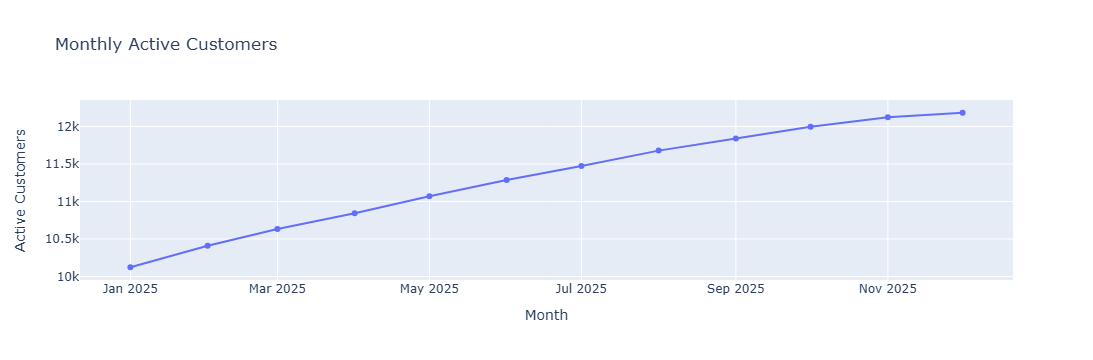

In [21]:
# Visualization
fig = px.line(
    monthly_active_customers,
    x = "billing_month",
    y = "active_customers",
    markers = True,
    title = "Monthly Active Customers"
)

fig.update_layout(
    xaxis_title = "Month",
    yaxis_title = "Active Customers"
)

fig.show()

### Monthly Active Customer Analysis

The active customer base increased consistently throughout 2025, growing from 10,123 customers in January to 12,184 customers in December.

This represents an overall increase of approximately 20.4% over the analysis period. The customer base grew every month, with no month-over-month declines observed.

The rate of growth gradually slowed over the course of the year. Monthly additions decreased from 287 customers between January and February to 59 customers between November and December. While the customer base continued to expand, the declining monthly additions suggest that growth momentum weakened toward the end of the year.

This trend warrants further investigation into the underlying drivers of customer growth and retention. The acquisition and churn analyses later in the notebook will help determine whether the slowing growth is primarily related to fewer new customers being acquired, increased churn, or a combination of both.

### Monthly Revenue
As the monthly_price column in monthly_billing already contains the actual price after discounts, I do not need to apply the discounted rate here.

In [22]:
# SQL query
monthly_revenue = pd.read_sql_query(
    """
    SELECT
        billing_month,
        SUM(monthly_price) AS monthly_recurring_revenue
    FROM monthly_billing
    GROUP BY billing_month
    ORDER BY billing_month;
    """,
    conn
)

monthly_revenue

,billing_month,monthly_recurring_revenue
0,2025-01-01 00:00:00,767646.00
1,2025-02-01 00:00:00,789155.50
2,2025-03-01 00:00:00,806678.75
3,2025-04-01 00:00:00,823170.00
4,2025-05-01 00:00:00,840250.75
5,2025-06-01 00:00:00,857081.50
6,2025-07-01 00:00:00,871007.50
7,2025-08-01 00:00:00,886713.75
8,2025-09-01 00:00:00,899828.75
9,2025-10-01 00:00:00,912475.75


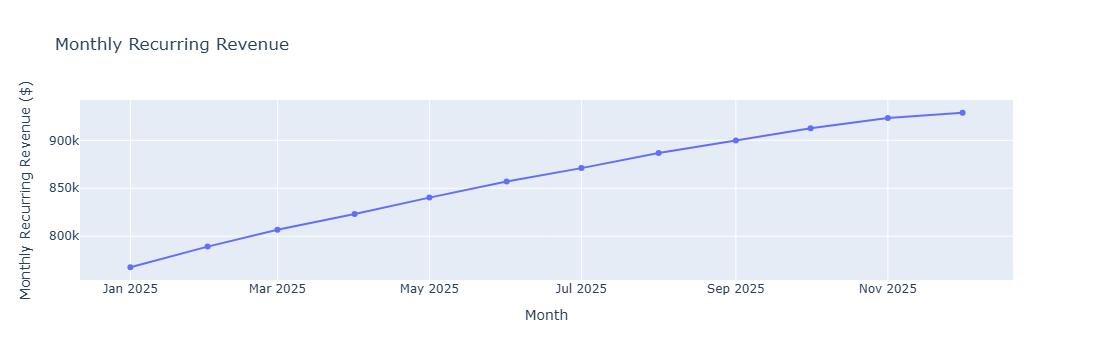

In [23]:
# Visualization
fig = px.line(
    monthly_revenue,
    x = "billing_month",
    y = "monthly_recurring_revenue",
    markers = True,
    title = "Monthly Recurring Revenue"
)

fig.update_layout(
    xaxis_title = "Month",
    yaxis_title = "Monthly Recurring Revenue ($)"
)

fig.show()

### Monthly Recurring Revenue Analysis

Monthly recurring revenue increased consistently throughout 2025, rising from 767,646 in January to 928,730 in December. This represents an overall increase of approximately 21.0% over the analysis period.

The MRR trend closely follows the growth in active customers, with revenue increasing every month and no monthly declines. However, MRR grew slightly faster than the active customer base, which suggests that revenue per active customer may have increased modestly over the year.

The consistent growth in recurring revenue indicates a steadily expanding subscription revenue base. The next step is to examine ARPU to determine whether the increase in MRR is primarily attributable to customer growth or whether changes in revenue per customer are also contributing.

### Average Revenue Per User (ARPU)

In [24]:
# SQL query
monthly_revenue_arpu = pd.read_sql_query(
    """
    SELECT
        billing_month,
        COUNT(DISTINCT customer_id) AS active_customers,
        SUM(monthly_price) AS monthly_recurring_revenue,
        SUM(monthly_price) / COUNT(DISTINCT customer_id) AS arpu
    FROM monthly_billing
    GROUP BY billing_month
    ORDER BY billing_month;
    """,
    conn
)

monthly_revenue_arpu

,billing_month,active_customers,monthly_recurring_revenue,arpu
0,2025-01-01 00:00:00,10123,767646.00,75.831868
1,2025-02-01 00:00:00,10410,789155.50,75.807445
2,2025-03-01 00:00:00,10633,806678.75,75.865584
3,2025-04-01 00:00:00,10843,823170.00,75.917182
4,2025-05-01 00:00:00,11071,840250.75,75.896554
5,2025-06-01 00:00:00,11288,857081.50,75.928552
6,2025-07-01 00:00:00,11475,871007.50,75.904793
7,2025-08-01 00:00:00,11679,886713.75,75.923773
8,2025-09-01 00:00:00,11841,899828.75,75.992632
9,2025-10-01 00:00:00,11996,912475.75,76.065001


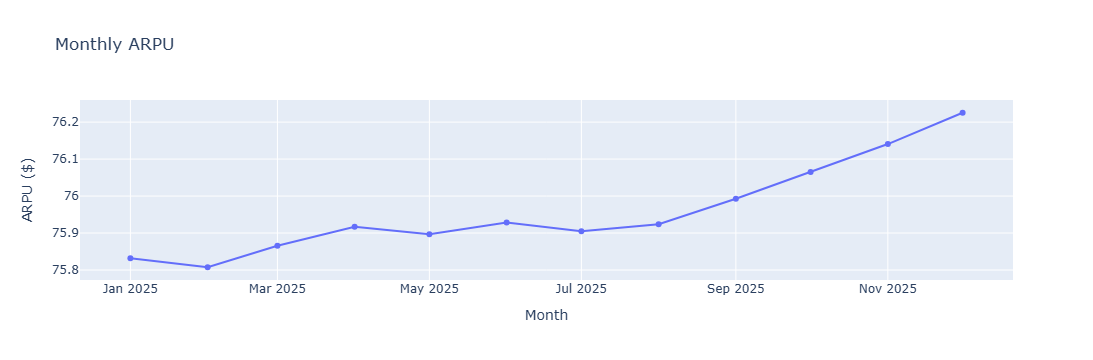

In [25]:
# Visualization
fig = px.line(
    monthly_revenue_arpu,
    x = "billing_month",
    y = "arpu",
    markers = True,
    title = "Monthly ARPU"
)

fig.update_layout(
    xaxis_title = "Month",
    yaxis_title = "ARPU ($)"
)

fig.show()

### Average Revenue Per User Analysis

ARPU remained relatively stable throughout 2025, with small month-to-month fluctuations. It began at 75.83 in January, dipped slightly in February, May, and July, and then increased consistently from August through December, reaching 76.23 at the end of the analysis period.

Overall, ARPU increased by approximately 0.5% during the year. While this change is modest compared with the 20.4% increase in active customers, it helps explain why MRR grew slightly faster than the customer base.

The relatively stable ARPU indicates that customer growth was the primary driver of recurring revenue growth. However, the gradual increase in ARPU during the second half of the year suggests that changes in customer or plan mix may also have contributed to revenue growth.

Further analysis of plan adoption and customer segments can help determine what factors contributed to the increase in revenue per active customer.

### Monthly Customer Additions
I will use the acquisition table grouped by month to investigate where the customer growth comes from

In [26]:
# SQL query
monthly_customer_additions = pd.read_sql_query(
    """
    SELECT
        strftime('%Y-%m-01', acquisition_date) AS acquisition_month,
        COUNT(DISTINCT customer_id) AS new_customers
    FROM acquisitions
    WHERE acquisition_date >= '2025-01-01'
        AND acquisition_date < '2026-01-01'
    GROUP BY acquisition_month
    ORDER BY acquisition_month;
    """,
    conn
)

monthly_customer_additions

,acquisition_month,new_customers
0,2025-01-01,361
1,2025-02-01,315
2,2025-03-01,307
3,2025-04-01,326
4,2025-05-01,328
5,2025-06-01,290
6,2025-07-01,337
7,2025-08-01,314
8,2025-09-01,314
9,2025-10-01,314


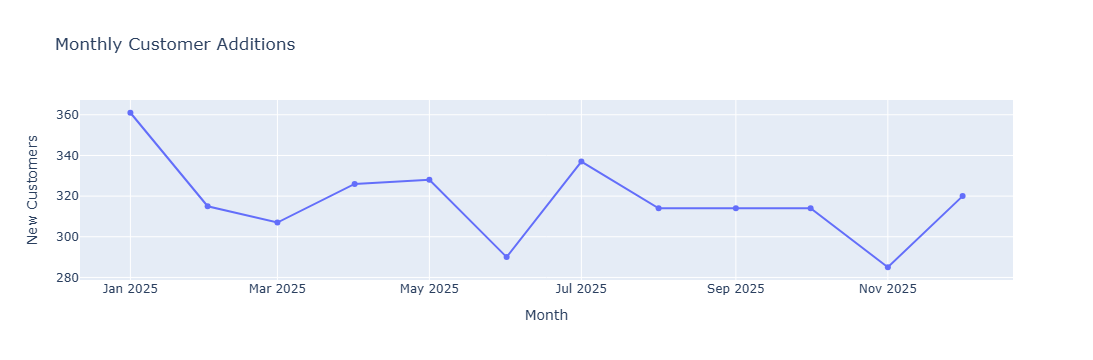

In [27]:
# Visualization
fig = px.line(
    monthly_customer_additions,
    x = "acquisition_month",
    y = "new_customers",
    markers = True,
    title = "Monthly Customer Additions"
)

fig.update_layout(
    xaxis_title = "Month",
    yaxis_title = "New Customers"
)

fig.show()

### Monthly Customer Additions Analysis

Customer additions remained relatively stable throughout 2025, ranging from 285 to 361 new customers per month. There is no clear upward or downward trend in acquisition volume.

The highest number of new customers was recorded in January at 361, while November had the lowest at 285. Despite these fluctuations, acquisition volume remained within a relatively narrow range throughout the year.

This indicates that the steady growth in the active customer base was not driven by a sustained increase in monthly customer acquisitions. The next step is to examine customer churn to determine how customer losses contributed to the changes in the active customer base.

### Monthly Churned Customers

This KPI measures the number of customers who churned during each month of the analysis period.

Examining churn alongside customer additions helps explain the changes observed in the active customer base. While customer additions remained relatively stable throughout 2025, changes in the number of customers leaving could affect the rate of net customer growth.

In [28]:
# SQL query
monthly_churn = pd.read_sql_query(
    """
    SELECT
        strftime('%Y-%m-01', churn_date) AS churn_month,
        COUNT(DISTINCT customer_id) AS churned_customers
    FROM customer_churn
    WHERE churn_date >= '2025-01-01'
        AND churn_date < '2026-01-01'
    GROUP BY churn_month
    ORDER BY churn_month;
    """,
    conn
)

monthly_churn

,churn_month,churned_customers
0,2025-01-01,70
1,2025-02-01,90
2,2025-03-01,95
3,2025-04-01,99
4,2025-05-01,105
5,2025-06-01,108
6,2025-07-01,133
7,2025-08-01,150
8,2025-09-01,159
9,2025-10-01,186


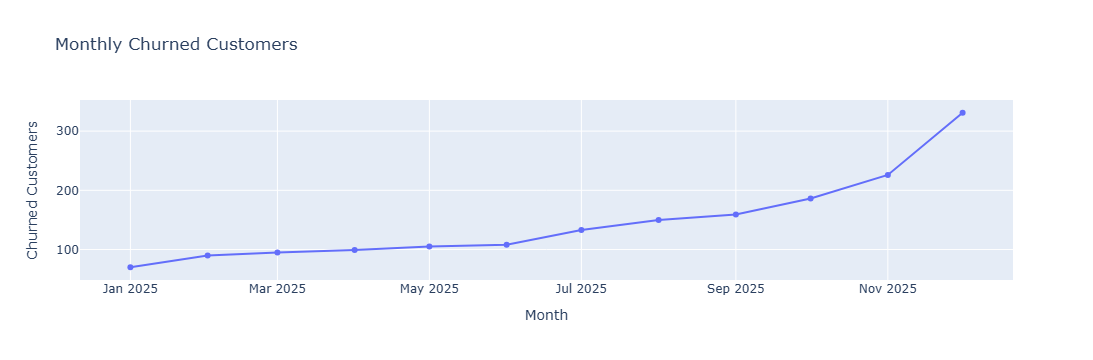

In [29]:
# Visualization
fig = px.line(
    monthly_churn,
    x = "churn_month",
    y = "churned_customers",
    markers = True,
    title = "Monthly Churned Customers"
)

fig.update_layout(
    xaxis_title = "Month",
    yaxis_title = "Churned Customers"
)

fig.show()

### Monthly Churn Analysis

Monthly churn increased throughout 2025, rising from 70 churned customers in January to 331 in December. The increase was gradual during the first half of the year before accelerating during the second half.

The sharpest increase occurred toward the end of the year. Monthly churn reached 186 customers in October, increased to 226 in November, and then rose to 331 in December.

This trend contrasts with customer additions, which remained relatively stable throughout the year. The increasing number of customers leaving the business therefore provides an important explanation for the slowing rate of net customer growth observed toward the end of the year.

The increase in churn warrants further investigation to determine which customer groups, plans, or customer characteristics are most strongly associated with churn.

### Net Customer Growth
This section will explore how he balance between customer additions and churn affected monthly customer growth

In [30]:
monthly_net_growth = pd.read_sql_query(
    """
    WITH monthly_acquisitions AS (
        SELECT
            strftime('%Y-%m-01', acquisition_date) AS month,
            COUNT(DISTINCT customer_id) AS new_customers
        FROM acquisitions
        WHERE acquisition_date >= '2025-01-01'
            AND acquisition_date < '2026-01-01'
        GROUP BY month
    ),

    monthly_churn AS (
        SELECT
            strftime('%Y-%m-01', churn_date) AS month,
            COUNT(DISTINCT customer_id) AS churned_customers
        FROM customer_churn
        WHERE churn_date >= '2025-01-01'
            AND churn_date< '2026-01-01'
        GROUP BY month
    )

    SELECT
        monthly_acquisitions.month,
        monthly_acquisitions.new_customers,
        COALESCE(monthly_churn.churned_customers, 0) AS churned_customers,
        monthly_acquisitions.new_customers - COALESCE(monthly_churn.churned_customers, 0) AS net_customer_growth
    FROM monthly_acquisitions
    LEFT JOIN monthly_churn
        ON monthly_acquisitions.month = monthly_churn.month
    ORDER BY monthly_acquisitions.month;
    """,
    conn
)

monthly_net_growth

,month,new_customers,churned_customers,net_customer_growth
0,2025-01-01,361,70,291
1,2025-02-01,315,90,225
2,2025-03-01,307,95,212
3,2025-04-01,326,99,227
4,2025-05-01,328,105,223
5,2025-06-01,290,108,182
6,2025-07-01,337,133,204
7,2025-08-01,314,150,164
8,2025-09-01,314,159,155
9,2025-10-01,314,186,128


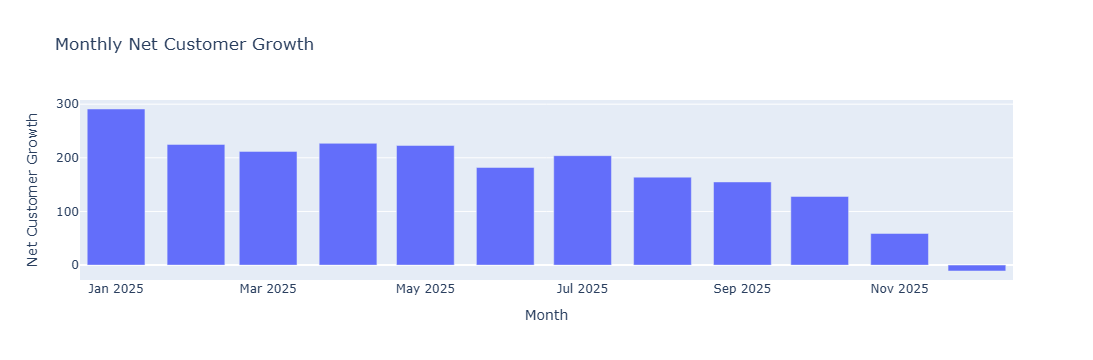

In [31]:
# Visualization
fig = px.bar(
    monthly_net_growth,
    x = "month",
    y = "net_customer_growth",
    title = "Monthly Net Customer Growth"
)

fig.update_layout(
    xaxis_title = "Month",
    yaxis_title = "Net Customer Growth"
)

fig.show()

### Net Customer Growth Analysis

Net customer growth declined substantially throughout 2025, falling from 291 customers in January to a net loss of 11 customers in December.

Although there were some temporary increases in net growth, including in April and July, the overall trend was downward. Net customer growth fell below 200 customers for the first time in June and continued to decline during the second half of the year.

The decline in net customer growth was primarily driven by increasing churn rather than a sustained decrease in customer additions. Monthly acquisitions remained relatively stable, while the number of customers leaving increased steadily throughout the year.

By December, churn exceeded customer additions, resulting in the first month of negative net customer growth during the analysis period. This helps explain why the active customer base continued to grow throughout the year but at a progressively slower rate.

The next stage of the analysis will investigate which customer groups and subscription characteristics are most strongly associated with churn.

## Customer Churn Analysis

The previous section identified increasing customer churn as the primary driver of declining net customer growth.

This section examines customer and subscription characteristics associated with churn to identify which groups may represent the greatest retention risk.

The analysis will examine churn across customer segments, subscription plans, contract types, and other relevant customer characteristics.

### Churn Rate by Customer Segment

In [32]:
# SQL query
segment_churn = pd.read_sql_query(
    """
    SELECT
        customers.customer_segment,
        COUNT(DISTINCT customers.customer_id) AS total_customers,
        COUNT(
            DISTINCT CASE
                WHEN customer_churn.churned = 1
                THEN customers.customer_id
            END
        ) AS churned_customers,
        ROUND(
        100.0 * COUNT(
            DISTINCT CASE
                WHEN customer_churn.churned = 1
                THEN customers.customer_id
            END
        )
        / COUNT(DISTINCT customers.customer_id),
        2
        ) AS churn_rate
    FROM customers
    LEFT JOIN customer_churn
        ON customers.customer_id = customer_churn.customer_id
    GROUP BY customers.customer_segment
    ORDER BY churn_rate DESC;
    """,
    conn
)

segment_churn

,customer_segment,total_customers,churned_customers,churn_rate
0,Consumer,12793,2493,19.49
1,Small Business,2207,344,15.59


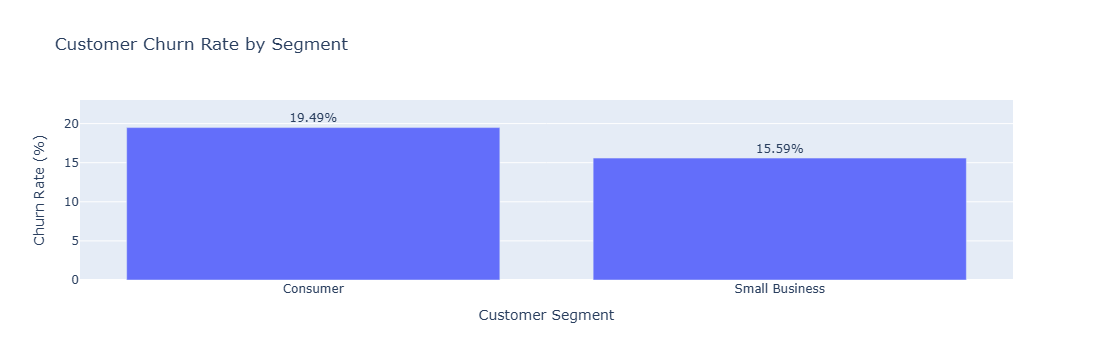

In [33]:
# Visualization
fig = px.bar(
    segment_churn,
    x = "customer_segment",
    y = "churn_rate",
    title = "Customer Churn Rate by Segment",
    text = "churn_rate"
)

fig.update_layout(
    xaxis_title = "Customer Segment",
    yaxis_title = "Churn Rate (%)"
)

fig.update_traces(
    texttemplate = "%{text:.2f}%",
    textposition = "outside"
)

fig.show()

### Churn Rate by Customer Segment Analysis

Consumer customers had a churn rate of 19.49%, compared with 15.59% for Small Business customers.

This indicates that Consumer customers are more likely to churn than Small Business customers, with a difference of 3.90 percentage points between the two segments.

Because Consumer customers also represent the majority of the customer base, they account for most of the total churned customers. The combination of a larger customer population and a higher churn rate makes the Consumer segment an important area for further retention analysis.

The next step is to examine churn by subscription plan to determine whether specific products or pricing tiers are associated with higher churn.

### Churn Rate by Subscription Plan

After identifying a higher churn rate among Consumer customers, this analysis examines churn across subscription plans to determine whether specific products are associated with greater retention risk.

Comparing churn rates rather than only churn counts allows us to account for differences in the number of customers subscribed to each plan.

In [34]:
# SQL query
plan_churn = pd.read_sql_query(
    """
    SELECT
        subscriptions.plan_name,
        COUNT(DISTINCT subscriptions.customer_id) AS total_customers,
        COUNT(
            DISTINCT CASE
                WHEN customer_churn.churned = 1
                THEN subscriptions.customer_id
            END
        ) AS churned_customers,
        ROUND(
            100.0 * COUNT(
                DISTINCT CASE
                    WHEN customer_churn.churned = 1
                    THEN subscriptions.customer_id
                END
            )
            / COUNT(DISTINCT subscriptions.customer_id),
            2
        ) AS churn_rate
    FROM subscriptions
    LEFT JOIN customer_churn
        ON subscriptions.customer_id = customer_churn.customer_id
    GROUP BY subscriptions.plan_name
    ORDER BY churn_rate DESC;
    """,
    conn
)

plan_churn

,plan_name,total_customers,churned_customers,churn_rate
0,Essential,3989,942,23.61
1,Standard,5522,1249,22.62
2,Business Pro,479,60,12.53
3,Premium,3570,419,11.74
4,Ultra,1440,167,11.60


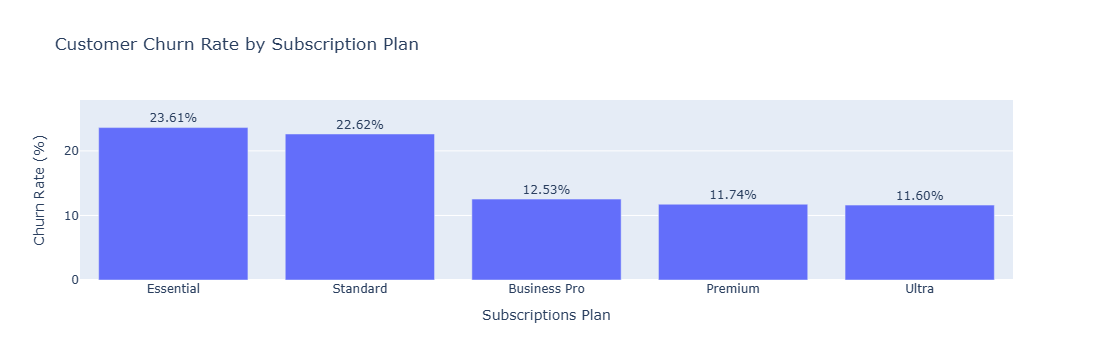

In [35]:
fig = px.bar(
    plan_churn,
    x = "plan_name",
    y = "churn_rate",
    title = "Customer Churn Rate by Subscription Plan",
    text = "churn_rate"
)

fig.update_layout(
    xaxis_title = "Subscriptions Plan",
    yaxis_title = "Churn Rate (%)"
)

fig.update_traces(
    texttemplate = "%{text:.2f}%",
    textposition = "outside"
)

fig.show()

### Churn Rate by Subscription Plan Analysis

Churn rates vary substantially across subscription plans. Essential had the highest churn rate at 23.61%, followed closely by Standard at 22.62%. In contrast, Business Pro, Premium, and Ultra had considerably lower churn rates, ranging from 11.60% to 12.53%.

The difference between the highest and lowest churn rates is approximately 12 percentage points. Customers on the Essential and Standard plans therefore appear to have substantially higher retention risk than customers on the other plans.

The higher churn rates on Essential and Standard are particularly important because these plans also have the largest customer populations in the dataset. This means they represent both a higher-risk group and a significant source of total churn.

The next analysis will examine contract type to determine whether the relationship between plan and churn may be associated with customer commitment levels.

### Churn Rate by Contract Type

The previous analysis identified substantial differences in churn across subscription plans. This analysis examines contract type to determine whether customer commitment is associated with retention.

Comparing churn rates between month-to-month and two-year contracts can help determine whether customers with longer contractual commitments have lower churn rates.

In [36]:
contract_churn = pd.read_sql_query(
    """
    SELECT
        subscriptions.contract_type,
        COUNT(DISTINCT subscriptions.customer_id) AS total_customers,
        COUNT(
            DISTINCT CASE
                WHEN customer_churn.churned = 1
                THEN subscriptions.customer_id
            END
        ) AS churned_customers,
        ROUND(
            100.0 * COUNT(
                DISTINCT CASE
                    WHEN customer_churn.churned = 1
                    Then subscriptions.customer_id
                END
            )
             / COUNT(DISTINCT subscriptions.customer_id),
             2
        ) AS churn_rate
    FROM subscriptions
    LEFT JOIN customer_churn
        ON subscriptions.customer_id = customer_churn.customer_id
    GROUP BY subscriptions.contract_type
    ORDER BY churn_rate DESC;
    """,
    conn
)

contract_churn

,contract_type,total_customers,churned_customers,churn_rate
0,Month-to-month,10027,2293,22.87
1,2-year,4973,544,10.94


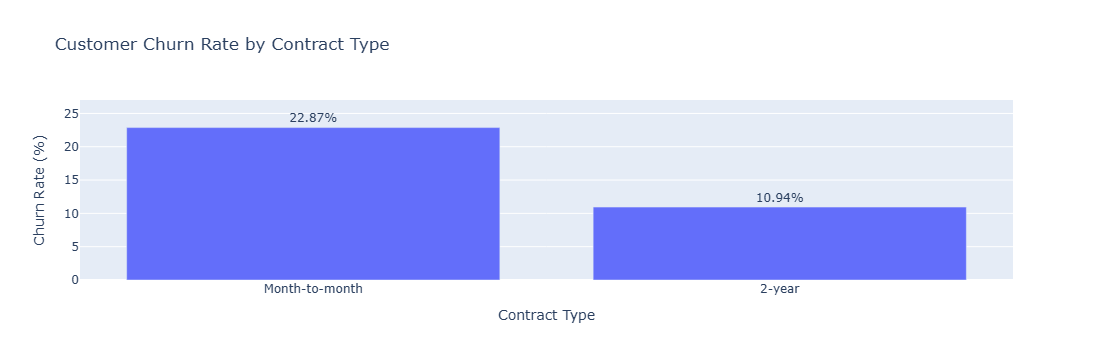

In [37]:
# Visualization
fig = px.bar(
    contract_churn,
    x = "contract_type",
    y = "churn_rate",
    title = "Customer Churn Rate by Contract Type",
    text = "churn_rate"
)

fig.update_layout(
    xaxis_title = "Contract Type",
    yaxis_title = "Churn Rate (%)"
)

fig.update_traces(
    texttemplate = "%{text:.2f}%",
    textposition = "outside"
)

fig.show()

### Churn Rate by Contract Type Analysis

Contract type shows a substantial difference in customer churn. Month-to-month customers had a churn rate of 22.87%, compared with 10.94% for customers on two-year contracts.

The churn rate for month-to-month customers was therefore approximately twice that of customers on two-year contracts, representing a difference of 11.93 percentage points.

This relationship provides an important potential explanation for the differences observed across subscription plans. Plans with a higher proportion of month-to-month customers may naturally experience higher churn.

While this analysis identifies a strong association between contract type and churn, it does not establish that contract type directly causes customers to churn. The next analysis will examine the relationship between contract type and subscription plan to determine whether the higher churn observed on Essential and Standard is partly explained by their contract mix.

### Contract Mix by Subscription Plan

The previous analyses identified substantial differences in churn by both subscription plan and contract type.

This analysis examines the distribution of contract types across subscription plans to determine whether the higher churn observed on Essential and Standard may be partly associated with differences in contract mix.

In [38]:
#SQL query
plan_contract_mix = pd.read_sql_query(
    """
    SELECT
        plan_name,
        contract_type,
        COUNT(DISTINCT customer_id) AS customers
    FROM subscriptions
    GROUP BY
        plan_name,
        contract_type
    ORDER BY
        plan_name,
        contract_type
    """,
    conn
)

plan_contract_mix

,plan_name,contract_type,customers
0,Business Pro,2-year,437
1,Business Pro,Month-to-month,42
2,Essential,Month-to-month,3989
3,Premium,2-year,3225
4,Premium,Month-to-month,345
5,Standard,Month-to-month,5522
6,Ultra,2-year,1311
7,Ultra,Month-to-month,129


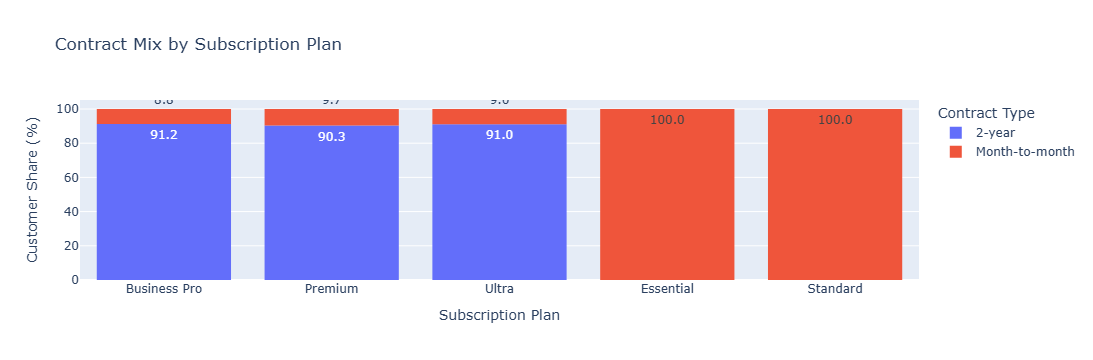

In [39]:
# Visualization
fig = px.histogram(
    plan_contract_mix,
    x = "plan_name",
    y = "customers",
    color = "contract_type",
    barnorm = "percent",
    text_auto = ".1f",
    title = "Contract Mix by Subscription Plan"
)

fig.update_layout(
    xaxis_title = "Subscription Plan",
    yaxis_title = "Customer Share (%)",
    legend_title = "Contract Type"
)

fig.show()

### Contract Mix by Subscription Plan Analysis

Contract mix varies substantially across subscription plans. Essential and Standard customers are exclusively on month-to-month contracts, while the other plans are overwhelmingly composed of two-year contracts.

Business Pro has approximately 8.8% of customers on month-to-month contracts, compared with approximately 9.7% for Premium and 9.0% for Ultra.

This provides important context for the earlier churn analysis. Essential and Standard had the highest churn rates, while month-to-month customers also had a substantially higher churn rate than customers on two-year contracts. Because Essential and Standard are entirely month-to-month in this dataset, the higher churn observed for these plans may be largely associated with their contract structure rather than the plans themselves.

This highlights the importance of examining multiple dimensions of customer behavior rather than attributing churn to a single characteristic. The next analysis should compare churn within contract types to determine whether subscription plan still has a meaningful relationship with churn after accounting for contract type.

### Churn Rate by Plan and Contract Type

The previous analysis showed that subscription plan and contract type are strongly associated in the dataset. Essential and Standard customers are exclusively on month-to-month contracts, while the other plans are predominantly on two-year contracts.

This analysis examines churn at the intersection of plan and contract type to determine whether differences in churn remain within the same contract structure.

This helps distinguish the relationship between plan and churn from the much stronger relationship already observed between contract type and churn.

In [40]:
# SQL query
plan_contract_churn = pd.read_sql_query(
    """
    SELECT
        subscriptions.plan_name,
        subscriptions.contract_type,
        COUNT(DISTINCT subscriptions.customer_id) AS total_customers,
        COUNT(
            DISTINCT CASE
                WHEN customer_churn.churned = 1
                THEN subscriptions.customer_id
            END
        ) AS churned_customers,
        ROUND(
            100.0 * COUNT(
                DISTINCT CASE
                    WHEN customer_churn.churned = 1
                    THEN subscriptions.customer_id
                END
            )
            / COUNT(DISTINCT subscriptions.customer_id),
            2
        ) AS churn_rate
    FROM subscriptions
    LEFT JOIN customer_churn
        ON subscriptions.customer_id = customer_churn.customer_id
    GROUP BY
        subscriptions.plan_name,
        subscriptions.contract_type
    ORDER BY
        subscriptions.plan_name,
        churn_rate DESC;
    """,
    conn
)

plan_contract_churn

,plan_name,contract_type,total_customers,churned_customers,churn_rate
0,Business Pro,Month-to-month,42,8,19.05
1,Business Pro,2-year,437,52,11.90
2,Essential,Month-to-month,3989,942,23.61
3,Premium,Month-to-month,345,68,19.71
4,Premium,2-year,3225,351,10.88
5,Standard,Month-to-month,5522,1249,22.62
6,Ultra,Month-to-month,129,26,20.16
7,Ultra,2-year,1311,141,10.76


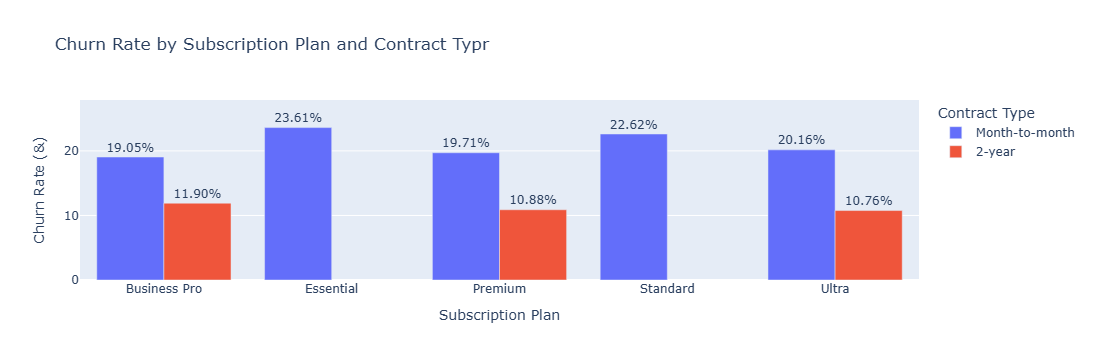

In [41]:
# Visualization
fig = px.bar(
    plan_contract_churn,
    x = "plan_name",
    y = "churn_rate",
    color = "contract_type",
    barmode = "group",
    text = "churn_rate",
    title = "Churn Rate by Subscription Plan and Contract Typr"
)

fig.update_layout(
    xaxis_title = "Subscription Plan",
    yaxis_title = "Churn Rate (&)",
    legend_title = "Contract Type"
)

fig.update_traces(
    texttemplate = "%{text:.2f}%",
    textposition = "outside"
)

fig.show()

### Churn Rate by Plan and Contract Type Analysis

Examining churn by both subscription plan and contract type provides further evidence that contract structure is strongly associated with customer retention.

For the plans that include both contract types, month-to-month customers consistently had higher churn rates than customers on two-year contracts. Premium customers, for example, had a churn rate of 19.71% on month-to-month contracts compared with 10.88% on two-year contracts.

Business Pro and Ultra showed a similar pattern, although their month-to-month customer populations were relatively small and should therefore be interpreted with more caution.

These results suggest that the relationship between contract type and churn persists even within the same subscription plan. This strengthens the conclusion that contract structure is an important characteristic associated with customer retention.

Essential and Standard cannot be directly compared with their two-year equivalents because all customers on these plans are month-to-month. Their higher churn rates may therefore reflect a combination of plan characteristics and the lack of longer-term contractual commitment.

The next analysis will examine additional customer characteristics to identify other factors associated with churn.

### Churn Rate by Support Ticket Activity

The previous analysis identified contract type as a strong characteristic associated with customer churn. This analysis examines whether customer support activity is also associated with retention.

Customers are divided into two groups: those who submitted at least one support ticket and those who did not submit any tickets during the analysis period.

Comparing churn rates between these groups can help determine whether customers who require support may represent a higher retention risk.

In [42]:
# SQL query
support_churn = pd.read_sql_query(
    """
    SELECT
        CASE
            WHEN ticket_summary.ticket_count > 0
                THEN 'Has Support Ticket'
            ELSE 'No Support Ticket'
        END AS support_status,
        COUNT(DISTINCT customers.customer_id) AS total_customers,
        COUNT(
            DISTINCT CASE
                WHEN customer_churn.churned = 1
                    THEN customers.customer_id
                END
        ) AS churned_customers,
        ROUND(
            100.0 * COUNT(
                DISTINCT CASE
                    WHEN customer_churn.churned = 1
                        THEN customers.customer_id
                    END
            )
            / COUNT(DISTINCT customers.customer_id),
            2
        ) AS churn_rate
    FROM customers
    LEFT JOIN (
        SELECT
            customer_id,
            COUNT(ticket_id) AS ticket_count
        FROM support_tickets
        GROUP BY customer_id
    ) AS ticket_summary
        ON customers.customer_id = ticket_summary.customer_id
    LEFT JOIN customer_churn
        ON customers.customer_id = customer_churn.customer_id
    GROUP BY support_status
    ORDER BY churn_rate DESC;
    """,
    conn
)

support_churn

,support_status,total_customers,churned_customers,churn_rate
0,Has Support Ticket,10546,2087,19.79
1,No Support Ticket,4454,750,16.84


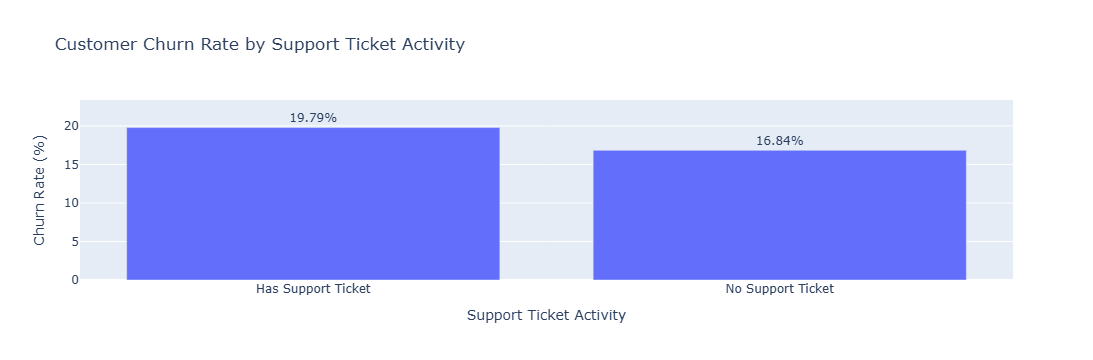

In [43]:
# Visualization
fig = px.bar(
    support_churn,
    x = "support_status",
    y = "churn_rate",
    title = "Customer Churn Rate by Support Ticket Activity",
    text = "churn_rate"
)

fig.update_layout(
    xaxis_title = "Support Ticket Activity",
    yaxis_title = "Churn Rate (%)"
)

fig.update_traces(
    texttemplate = "%{text:.2f}%",
    textposition = "outside"
)

fig.show()

### Churn Rate by Support Ticket Activity Analysis

Customers who submitted at least one support ticket had a churn rate of 19.79%, compared with 16.84% for customers who did not submit a support ticket.

This represents a difference of 2.95 percentage points, suggesting that customers who require support may have a higher risk of churn.

However, this analysis identifies an association rather than a causal relationship. Customers may submit support tickets because they are experiencing service or account issues, which could also contribute to their decision to churn.

Further analysis of support ticket volume and resolution outcomes can help determine whether customers with more frequent or unresolved support issues are associated with higher churn rates.

### Churn Rate by Support Ticket Volume

The previous analysis found that customers who submitted support tickets had a higher churn rate than those who did not.

This analysis examines whether churn rates differ based on the number of support tickets submitted. Customers are grouped by ticket volume to determine whether customers with more frequent support interactions are associated with greater retention risk.

In [44]:
# SQL query
ticket_volume_churn = pd.read_sql_query(
    """
    WITH ticket_counts AS (
        SELECT
            customer_id,
            COUNT(ticket_id) AS ticket_count
        FROM support_tickets
        GROUP BY customer_id
    ),
    customer_ticket_groups AS (
        SELECT
            customers.customer_id,
            CASE
                WHEN COALESCE(ticket_counts.ticket_count, 0) = 0
                    THEN 'No Tickets'
                WHEN ticket_counts.ticket_count = 1
                    THEN '1 Ticket'
                WHEN ticket_counts.ticket_count BETWEEN 2 AND 3
                    THEN '2-3 Tickets'
                ELSE '4+ Tickets'
            END AS ticket_volume,
            customer_churn.churned
        FROM customers
        LEFT JOIN ticket_counts
            ON customers.customer_id = ticket_counts.customer_id
        LEFT JOIN customer_churn
            ON customers.customer_id = customer_churn.customer_id
    )
    SELECT
        ticket_volume,
        COUNT(DISTINCT customer_id) AS total_customers,
        COUNT(
            DISTINCT CASE
                WHEN churned = 1
                THEN customer_id
            END
        ) AS churned_customers,
        ROUND(
            100.0 * COUNT(
                DISTINCT CASE
                    WHEN churned = 1
                    THEN customer_id
                END
            )
            / COUNT(DISTINCT customer_id),
            2
        ) AS churn_rate
    FROM customer_ticket_groups
    GROUP BY ticket_volume
    ORDER BY
        CASE ticket_volume
            WHEN 'No Tickets' THEN 1
            WHEN '1 Ticket' THEN 2
            WHEN '2-3 Tickets' THEN 3
            WHEN '4+ Tickets' THEN 4
        END;
    """,
    conn
)

ticket_volume_churn

,ticket_volume,total_customers,churned_customers,churn_rate
0,No Tickets,4454,750,16.84
1,1 Ticket,5512,1027,18.63
2,2-3 Tickets,4562,924,20.25
3,4+ Tickets,472,136,28.81


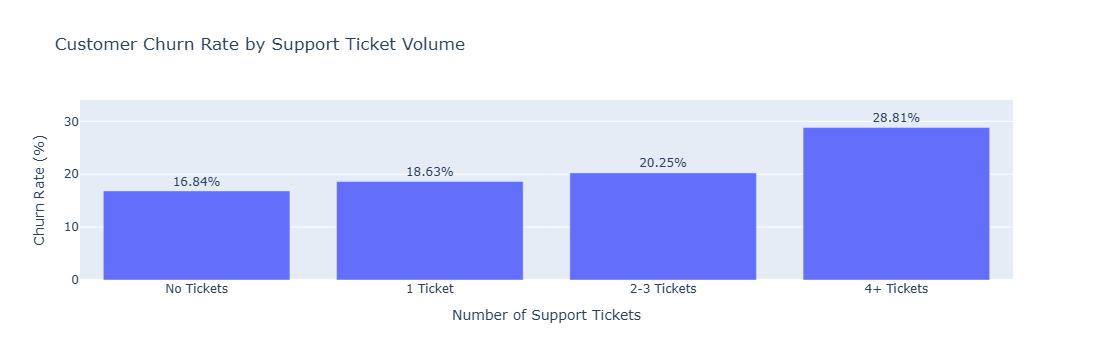

In [45]:
# Visualization
fig = px.bar(
    ticket_volume_churn,
    x="ticket_volume",
    y="churn_rate",
    title="Customer Churn Rate by Support Ticket Volume",
    text="churn_rate"
)

fig.update_layout(
    xaxis_title="Number of Support Tickets",
    yaxis_title="Churn Rate (%)"
)

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside"
)

fig.show()

### Churn Rate by Support Ticket Volume Analysis

Churn rates increased consistently as support ticket volume increased. Customers with no support tickets had the lowest churn rate at 16.84%, followed by customers with one ticket at 18.63% and customers with two to three tickets at 20.25%.

Customers with four or more support tickets had the highest churn rate at 28.81%, representing an increase of 11.97 percentage points compared with customers who submitted no support tickets.

The consistent increase in churn across ticket-volume groups suggests a strong association between frequent support interactions and customer retention risk. Customers with multiple support issues may represent an important group for proactive retention efforts.

However, this analysis does not establish that submitting more support tickets directly causes churn. Higher ticket volume may reflect underlying service, billing, or account issues that contribute to both increased support activity and a greater likelihood of leaving.

The next analysis will examine support ticket outcomes to determine whether unresolved issues are also associated with higher churn.

### Churn Rate by Support Ticket Resolution

The previous analysis found that churn rates increased as customers submitted more support tickets.

This analysis examines whether unresolved support issues are also associated with customer churn. Customers will be grouped based on whether they have any unresolved support tickets, allowing us to determine whether unresolved issues represent an additional retention risk.

In [46]:
# SQL Query
unresolved_ticket_churn = pd.read_sql_query(
    """
    WITH ticket_status AS (
        SELECT
            customer_id,
            SUM(
                CASE
                    WHEN resolution_status != 'Resolved'
                    THEN 1
                    ELSE 0
                END
            ) AS unresolved_tickets
        FROM support_tickets
        GROUP BY customer_id
    ),

    customer_support_status AS (
        SELECT
            customers.customer_id,
            CASE
                WHEN COALESCE(ticket_status.unresolved_tickets, 0) > 0
                    THEN 'Has Unresolved Ticket'
                ELSE 'No Unresolved Tickets'
            END AS resolution_status,
            customer_churn.churned
        FROM customers
        LEFT JOIN ticket_status
            ON customers.customer_id = ticket_status.customer_id
        LEFT JOIN customer_churn
            ON customers.customer_id = customer_churn.customer_id
    )

    SELECT
        resolution_status,
        COUNT(DISTINCT customer_id) AS total_customers,
        COUNT(
            DISTINCT CASE
                WHEN churned = 1
                THEN customer_id
            END
        ) AS churned_customers,
        ROUND(
            100.0 * COUNT(
                DISTINCT CASE
                    WHEN churned = 1
                    THEN customer_id
                END
            )
            / COUNT(DISTINCT customer_id),
            2
        ) AS churn_rate
    FROM customer_support_status
    GROUP BY resolution_status
    ORDER BY churn_rate DESC;
    """,
    conn
)

unresolved_ticket_churn

,resolution_status,total_customers,churned_customers,churn_rate
0,Has Unresolved Ticket,857,233,27.19
1,No Unresolved Tickets,14143,2604,18.41


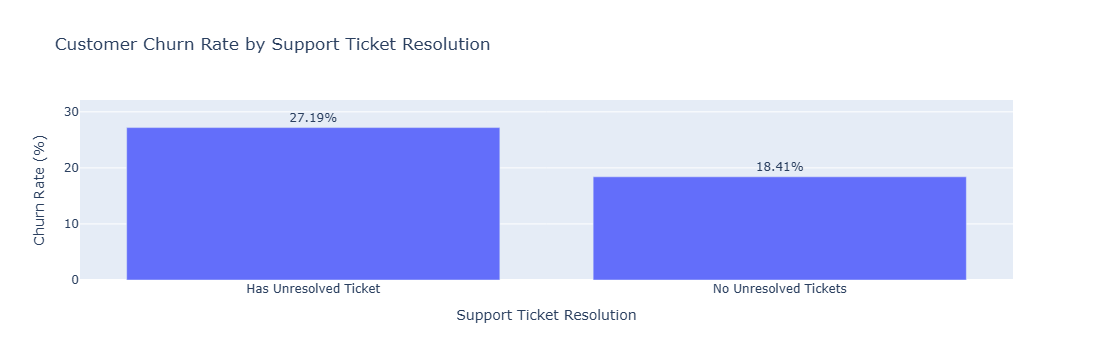

In [47]:
# Visualization
fig = px.bar(
    unresolved_ticket_churn,
    x="resolution_status",
    y="churn_rate",
    title="Customer Churn Rate by Support Ticket Resolution",
    text="churn_rate"
)

fig.update_layout(
    xaxis_title="Support Ticket Resolution",
    yaxis_title="Churn Rate (%)"
)

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside"
)

fig.show()

### Churn Rate by Support Ticket Resolution Analysis

Customers with at least one unresolved support ticket had a churn rate of 27.19%, compared with 18.41% for customers with no unresolved tickets.

This represents a difference of 8.78 percentage points, indicating a substantial association between unresolved support issues and customer churn. Customers with unresolved tickets had a churn rate approximately 1.5 times higher than customers without unresolved tickets.

The result suggests that unresolved support issues may represent an important retention risk. This finding is particularly relevant when considered alongside the earlier analysis showing that churn increased as support ticket volume increased.

However, the analysis does not establish that unresolved tickets directly cause customers to churn. Unresolved issues may instead be an indicator of underlying service problems or customer dissatisfaction.

Only 857 customers had unresolved tickets compared with 14,143 customers without unresolved tickets, so the unresolved group is considerably smaller. The higher churn rate should therefore be interpreted alongside the difference in group size.

The next analysis will examine whether longer support resolution times are also associated with higher customer churn.

### Churn Rate by Ticket Resolution Time

The previous analysis found that customers with unresolved support tickets had a substantially higher churn rate than customers without unresolved tickets.

This analysis examines whether the time required to resolve support tickets is also associated with customer churn. Customers with resolved tickets will be grouped by average resolution time to determine whether longer resolution times are associated with greater retention risk.

In [48]:
# SQL query
resolution_time_churn = pd.read_sql_query(
    """
    WITH customer_resolution AS (
        SELECT
            customer_id,
            AVG(resolution_time_hours) AS avg_resolution_hours
        FROM support_tickets
        WHERE resolution_status = 'Resolved'
        GROUP BY customer_id
    ),

    customer_resolution_groups AS (
        SELECT
            customers.customer_id,
            CASE
                WHEN customer_resolution.avg_resolution_hours IS NULL
                    THEN 'No Resolved Tickets'
                WHEN customer_resolution.avg_resolution_hours < 24
                    THEN 'Under 24 Hours'
                WHEN customer_resolution.avg_resolution_hours < 48
                    THEN '24-48 Hours'
                ELSE 'Over 48 Hours'
            END AS resolution_time_group,
            customer_churn.churned
        FROM customers
        LEFT JOIN customer_resolution
            ON customers.customer_id = customer_resolution.customer_id
        LEFT JOIN customer_churn
            ON customers.customer_id = customer_churn.customer_id
    )

    SELECT
        resolution_time_group,
        COUNT(DISTINCT customer_id) AS total_customers,
        COUNT(
            DISTINCT CASE
                WHEN churned = 1
                THEN customer_id
            END
        ) AS churned_customers,
        ROUND(
            100.0 * COUNT(
                DISTINCT CASE
                    WHEN churned = 1
                    THEN customer_id
                END
            )
            / COUNT(DISTINCT customer_id),
            2
        ) AS churn_rate
    FROM customer_resolution_groups
    GROUP BY resolution_time_group
    ORDER BY
        CASE resolution_time_group
            WHEN 'No Resolved Tickets' THEN 1
            WHEN 'Under 24 Hours' THEN 2
            WHEN '24-48 Hours' THEN 3
            WHEN 'Over 48 Hours' THEN 4
        END;
    """,
    conn
)

resolution_time_churn

,resolution_time_group,total_customers,churned_customers,churn_rate
0,No Resolved Tickets,4713,818,17.36
1,Under 24 Hours,5094,1005,19.73
2,24-48 Hours,4009,803,20.03
3,Over 48 Hours,1184,211,17.82


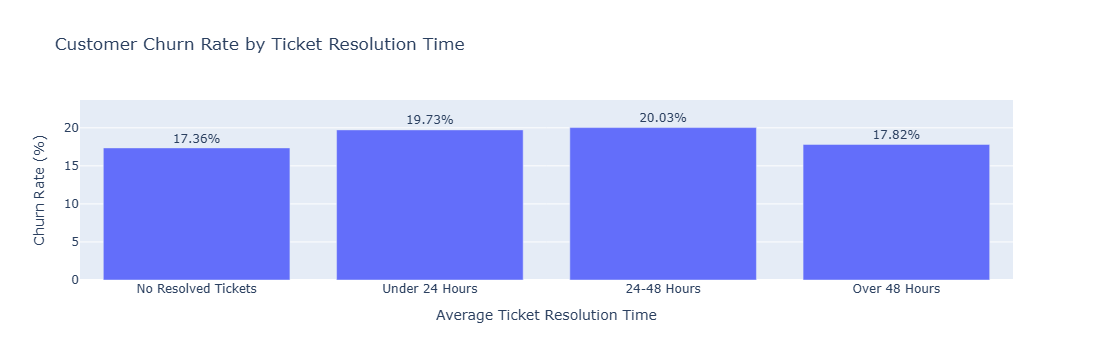

In [49]:
# Visualization
fig = px.bar(
    resolution_time_churn,
    x="resolution_time_group",
    y="churn_rate",
    title="Customer Churn Rate by Ticket Resolution Time",
    text="churn_rate"
)

fig.update_layout(
    xaxis_title="Average Ticket Resolution Time",
    yaxis_title="Churn Rate (%)"
)

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside"
)

fig.show()

### Churn Rate by Ticket Resolution Time Analysis

Churn rates do not show a consistent relationship with average ticket resolution time.

Customers with no resolved tickets had a churn rate of 17.36%, while customers whose tickets were resolved in under 24 hours had a churn rate of 19.73%. The 24–48 hour group had the highest churn rate at 20.03%.

However, churn decreased to 17.82% among customers with average resolution times over 48 hours. This means that longer resolution times were not consistently associated with higher churn in the dataset.

The relatively similar churn rates across the resolution-time groups suggest that resolution time alone may not be a strong predictor of churn. This contrasts with the clearer relationships observed for support ticket volume and unresolved tickets.

The analysis therefore suggests that the existence and frequency of support issues may be more relevant to customer retention than the average time required to resolve those issues.

## Churn Rate by Customer Age Group

The previous analyses identified several support-related characteristics associated with customer churn. This section examines customer demographics to determine whether churn varies across different age groups.

Understanding whether certain age groups have higher churn rates can help identify customer populations that may require different retention strategies.

In [50]:
# For the SQL query I will calculate age from date_of_birth and group he customers into age ranges
age_churn = pd.read_sql_query(
    """
    WITH customer_ages AS (
        SELECT
            customer_id,
            CAST(
                (julianday('2025-12-31') - julianday(date_of_birth))
                / 365.25
                AS INTEGER
            ) AS age
        FROM customers
    ),

    customer_age_groups AS (
        SELECT
            customer_id,
            CASE
                WHEN age < 25
                    THEN 'Under 25'
                WHEN age BETWEEN 25 AND 34
                    THEN '25-34'
                WHEN age BETWEEN 35 AND 44
                    THEN '35-44'
                WHEN age BETWEEN 45 AND 54
                    THEN '45-54'
                ELSE '55+'
            END AS age_group
        FROM customer_ages
    )

    SELECT
        customer_age_groups.age_group,
        COUNT(DISTINCT customer_age_groups.customer_id)
            AS total_customers,
        COUNT(
            DISTINCT CASE
                WHEN customer_churn.churned = 1
                THEN customer_age_groups.customer_id
            END
        ) AS churned_customers,
        ROUND(
            100.0 * COUNT(
                DISTINCT CASE
                    WHEN customer_churn.churned = 1
                    THEN customer_age_groups.customer_id
                END
            )
            / COUNT(DISTINCT customer_age_groups.customer_id),
            2
        ) AS churn_rate
    FROM customer_age_groups
    LEFT JOIN customer_churn
        ON customer_age_groups.customer_id = customer_churn.customer_id
    GROUP BY customer_age_groups.age_group
    ORDER BY
        CASE customer_age_groups.age_group
            WHEN 'Under 25' THEN 1
            WHEN '25-34' THEN 2
            WHEN '35-44' THEN 3
            WHEN '45-54' THEN 4
            WHEN '55+' THEN 5
        END;
    """,
    conn
)

age_churn

,age_group,total_customers,churned_customers,churn_rate
0,Under 25,1863,357,19.16
1,25-34,2597,493,18.98
2,35-44,2640,473,17.92
3,45-54,2692,540,20.06
4,55+,5208,974,18.70


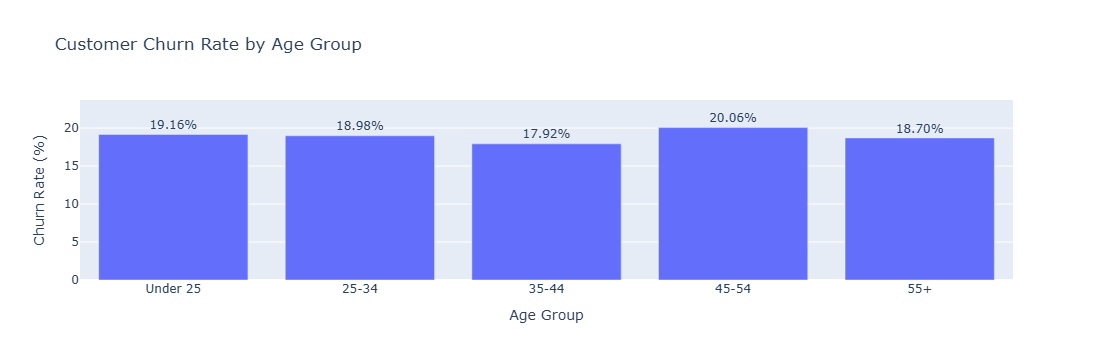

In [51]:
# Visualization
fig = px.bar(
    age_churn,
    x="age_group",
    y="churn_rate",
    title="Customer Churn Rate by Age Group",
    text="churn_rate"
)

fig.update_layout(
    xaxis_title="Age Group",
    yaxis_title="Churn Rate (%)"
)

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside"
)

fig.show()

### Churn Rate by Customer Age Group Analysis

Churn rates were relatively consistent across age groups, ranging from 17.92% among customers aged 35–44 to 20.06% among customers aged 45–54.

The overall difference between the highest and lowest churn rates was only 2.14 percentage points, considerably smaller than the differences observed for contract type, subscription plan, and support-related characteristics.

There is also no clear directional trend between age and churn. The 45–54 group had the highest churn rate, while the 35–44 group had the lowest, but the remaining age groups fell within a relatively narrow range.

Based on these results, age does not appear to be a major differentiating factor for customer churn in this dataset. Customer characteristics such as contract type and support experience show substantially stronger associations with retention.

## Churn Rate by Customer Segment and Contract Type

Earlier analysis found that Consumer customers had a higher overall churn rate than Small Business customers.

However, contract type has a much stronger relationship with churn, with month-to-month customers having substantially higher churn than customers on two-year contracts.

This analysis examines churn by both customer segment and contract type to determine whether the difference between Consumer and Small Business customers remains after accounting for contract structure.

In [52]:
# SQL query
segment_contract_churn = pd.read_sql_query(
    """
    SELECT
        customers.customer_segment,
        subscriptions.contract_type,
        COUNT(DISTINCT customers.customer_id) AS total_customers,
        COUNT(
            DISTINCT CASE
                WHEN customer_churn.churned = 1
                THEN customers.customer_id
            END
        ) AS churned_customers,
        ROUND(
            100.0 * COUNT(
                DISTINCT CASE
                    WHEN customer_churn.churned = 1
                    THEN customers.customer_id
                END
            )
            / COUNT(DISTINCT customers.customer_id),
            2
        ) AS churn_rate
    FROM customers
    LEFT JOIN subscriptions
        ON customers.customer_id = subscriptions.customer_id
    LEFT JOIN customer_churn
        ON customers.customer_id = customer_churn.customer_id
    GROUP BY
        customers.customer_segment,
        subscriptions.contract_type
    ORDER BY
        customers.customer_segment,
        churn_rate DESC;
    """,
    conn
)

segment_contract_churn

,customer_segment,contract_type,total_customers,churned_customers,churn_rate
0,Consumer,Month-to-month,9320,2114,22.68
1,Consumer,2-year,3473,379,10.91
2,Small Business,Month-to-month,707,179,25.32
3,Small Business,2-year,1500,165,11.00


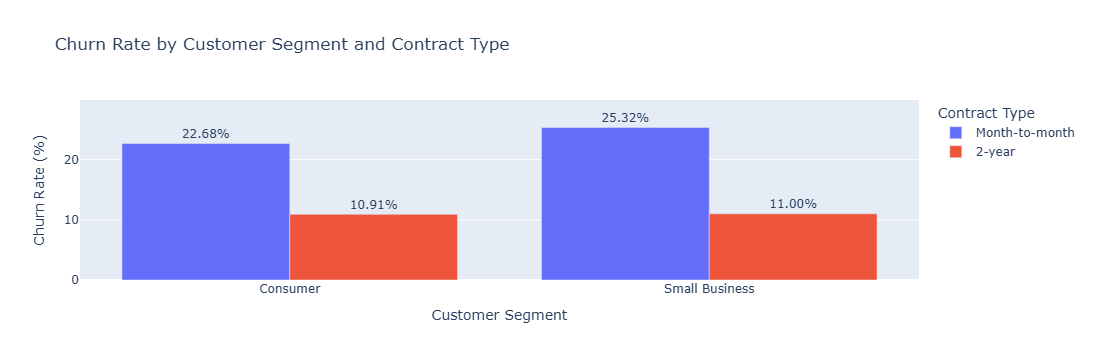

In [53]:
# Visualization
fig = px.bar(
    segment_contract_churn,
    x="customer_segment",
    y="churn_rate",
    color="contract_type",
    barmode="group",
    text="churn_rate",
    title="Churn Rate by Customer Segment and Contract Type"
)

fig.update_layout(
    xaxis_title="Customer Segment",
    yaxis_title="Churn Rate (%)",
    legend_title="Contract Type"
)

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside"
)

fig.show()

## Churn Rate by Customer Segment and Contract Type Analysis

The earlier analysis showed a difference in overall churn rates between Consumer and Small Business customers. However, examining the two segments within each contract type provides important additional context.

Month-to-month customers had substantially higher churn than two-year customers in both segments. Consumer customers had a churn rate of 22.68% on month-to-month contracts and 10.91% on two-year contracts. Small Business customers showed a similar pattern, with churn rates of 25.32% and 11.00%, respectively.

The difference between the two customer segments was relatively small within each contract type. Small Business customers had a 2.64 percentage-point higher churn rate among month-to-month customers, while the difference among two-year customers was only 0.09 percentage points.

These results suggest that contract type is a much stronger factor associated with churn than customer segment. The overall difference observed between segments appears to be influenced substantially by their contract mix rather than representing a large difference in retention behavior between Consumer and Small Business customers.

This reinforces the importance of controlling for related customer characteristics when evaluating churn drivers.

## Monthly Recurring Revenue by Customer Segment

The previous analyses examined customer growth, revenue, and churn at the overall customer level. This section breaks recurring revenue down by customer segment to determine how each segment contributes to the company's monthly recurring revenue.

Comparing revenue contribution with customer counts can help identify whether certain segments generate disproportionately more recurring revenue.

In [54]:
# SQL query
segment_mrr = pd.read_sql_query(
    """
    SELECT
        monthly_billing.billing_month,
        customers.customer_segment,
        ROUND(
            SUM(monthly_billing.monthly_price),
            2
        ) AS monthly_recurring_revenue
    FROM monthly_billing
    LEFT JOIN customers
        ON monthly_billing.customer_id = customers.customer_id
    WHERE monthly_billing.billing_month >= '2025-01-01'
        AND monthly_billing.billing_month < '2026-01-01'
    GROUP BY
        monthly_billing.billing_month,
        customers.customer_segment
    ORDER BY
        monthly_billing.billing_month,
        customers.customer_segment;
    """,
    conn
)

segment_mrr

,billing_month,customer_segment,monthly_recurring_revenue
0,2025-01-01 00:00:00,Consumer,616660.00
1,2025-01-01 00:00:00,Small Business,150986.00
2,2025-02-01 00:00:00,Consumer,634462.75
3,2025-02-01 00:00:00,Small Business,154692.75
4,2025-03-01 00:00:00,Consumer,648509.25
5,2025-03-01 00:00:00,Small Business,158169.50
6,2025-04-01 00:00:00,Consumer,661404.00
7,2025-04-01 00:00:00,Small Business,161766.00
8,2025-05-01 00:00:00,Consumer,675935.00
9,2025-05-01 00:00:00,Small Business,164315.75


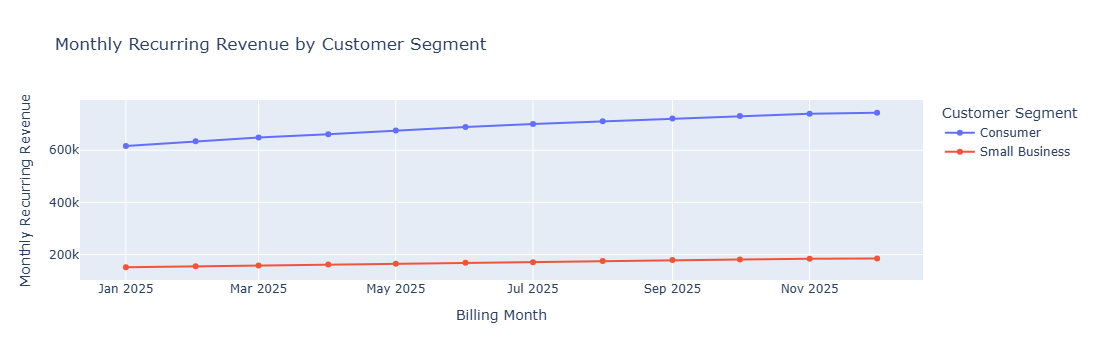

In [55]:
# Visualization
fig = px.line(
    segment_mrr,
    x="billing_month",
    y="monthly_recurring_revenue",
    color="customer_segment",
    markers=True,
    title="Monthly Recurring Revenue by Customer Segment"
)

fig.update_layout(
    xaxis_title="Billing Month",
    yaxis_title="Monthly Recurring Revenue",
    legend_title="Customer Segment"
)

fig.show()

## Monthly Recurring Revenue by Customer Segment Analysis

Monthly recurring revenue increased consistently for both customer segments throughout 2025. Consumer MRR increased from 616,660.00 in January to 743,782.25 in December, while Small Business MRR increased from 150,986.00 to 184,947.50.

Consumer customers generated substantially more recurring revenue throughout the year, reflecting the much larger size of the Consumer customer base.

Both segments followed a similar upward trajectory, with recurring revenue increasing steadily throughout the year. This indicates that revenue growth was occurring across both customer segments rather than being driven exclusively by one segment.

The larger total revenue contribution from Consumer customers is primarily a result of the segment's larger customer base. Therefore, total MRR should be considered alongside customer volume when evaluating the relative importance of each segment.

The next analysis will examine recurring revenue by subscription plan to determine how revenue is distributed across the company's different pricing tiers.

## Monthly Recurring Revenue by Subscription Plan

The previous analysis showed that recurring revenue increased throughout 2025 across both customer segments.

This analysis examines monthly recurring revenue by subscription plan to determine which plans contribute the most revenue and how the revenue contribution of each plan changes over time.

Comparing MRR across plans can help identify which pricing tiers are most important to the company's recurring revenue base.

In [56]:
# SQL query
plan_mrr = pd.read_sql_query(
    """
    SELECT
        monthly_billing.billing_month,
        subscriptions.plan_name,
        ROUND(
            SUM(monthly_billing.monthly_price),
            2
        ) AS monthly_recurring_revenue
    FROM monthly_billing
    LEFT JOIN subscriptions
        ON monthly_billing.customer_id = subscriptions.customer_id
    WHERE monthly_billing.billing_month >= '2025-01-01'
        AND monthly_billing.billing_month < '2026-01-01'
    GROUP BY
        monthly_billing.billing_month,
        subscriptions.plan_name
    ORDER BY
        monthly_billing.billing_month,
        subscriptions.plan_name;
    """,
    conn
)

plan_mrr

,billing_month,plan_name,monthly_recurring_revenue
0,2025-01-01 00:00:00,Business Pro,46597.50
1,2025-01-01 00:00:00,Essential,130737.75
2,2025-01-01 00:00:00,Premium,221402.25
3,2025-01-01 00:00:00,Standard,254212.50
4,2025-01-01 00:00:00,Ultra,114696.00
5,2025-02-01 00:00:00,Business Pro,47887.50
6,2025-02-01 00:00:00,Essential,135236.75
7,2025-02-01 00:00:00,Premium,227952.50
8,2025-02-01 00:00:00,Standard,260178.75
9,2025-02-01 00:00:00,Ultra,117900.00


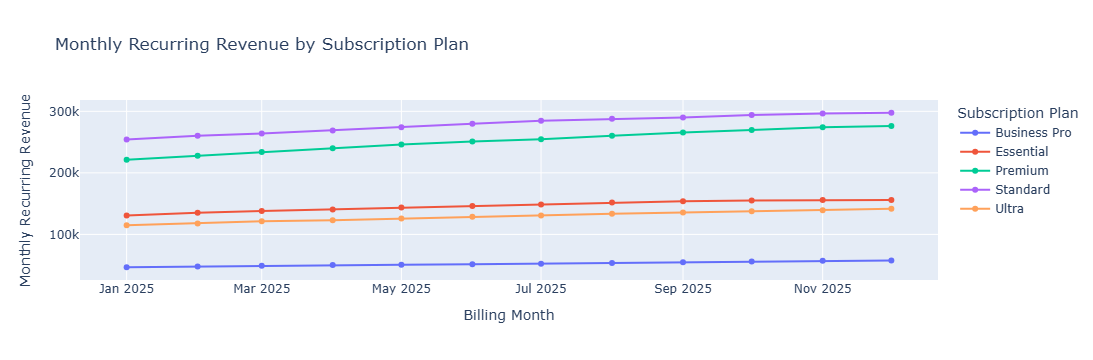

In [57]:
# Visualization
fig = px.line(
    plan_mrr,
    x="billing_month",
    y="monthly_recurring_revenue",
    color="plan_name",
    markers=True,
    title="Monthly Recurring Revenue by Subscription Plan"
)

fig.update_layout(
    xaxis_title="Billing Month",
    yaxis_title="Monthly Recurring Revenue",
    legend_title="Subscription Plan"
)

fig.show()

## Monthly Recurring Revenue by Subscription Plan Analysis

Monthly recurring revenue increased across all subscription plans throughout 2025, although the plans contributed substantially different amounts of revenue.

Standard generated the highest MRR throughout the entire analysis period, increasing from 254,212.50 in January to 297,712.50 in December. Premium consistently generated the second-highest MRR, increasing from 221,402.25 to 276,188.75 over the same period. Essential ranked third, followed by Ultra and Business Pro.

The high MRR contribution from Standard is notable because it is not the company's highest-priced plan. Its position as the largest revenue contributor is therefore driven primarily by its larger customer base rather than its price alone.

These results are particularly relevant when considered alongside the earlier churn analysis. Standard had a churn rate of 22.62%, making it one of the higher-churn plans while also being the company's largest source of recurring revenue. This makes retention among Standard customers an important potential lever for protecting recurring revenue.

Overall, recurring revenue growth was distributed across all five plans rather than being concentrated in a single subscription tier. However, the large revenue contribution and relatively high churn rate of Standard make it a particularly important plan to monitor.

## Average Customer Usage by Churn Status

The previous analyses identified several customer characteristics associated with churn, including contract type, subscription plan, and support activity.

This section examines customer usage behavior to determine whether customers who churn have different average usage levels than customers who remain active.

Understanding the relationship between usage and churn may help identify whether lower or higher engagement with the service is associated with increased retention risk.

In [58]:
# SQL Query
usage_churn = pd.read_sql_query(
    """
    WITH customer_usage AS (
        SELECT
            customer_id,
            AVG(data_usage_gb) AS avg_monthly_usage_gb
        FROM monthly_usage
        GROUP BY customer_id
    )

    SELECT
        CASE
            WHEN customer_churn.churned = 1
                THEN 'Churned'
            ELSE 'Active'
        END AS churn_status,
        COUNT(DISTINCT customer_usage.customer_id)
            AS total_customers,
        ROUND(
            AVG(customer_usage.avg_monthly_usage_gb),
            2
        ) AS average_monthly_usage_gb
    FROM customer_usage
    LEFT JOIN customer_churn
        ON customer_usage.customer_id = customer_churn.customer_id
    GROUP BY
        churn_status
    ORDER BY
        churn_status;
    """,
    conn
)

usage_churn

,churn_status,total_customers,average_monthly_usage_gb
0,Active,11936,489.90
1,Churned,1605,425.85


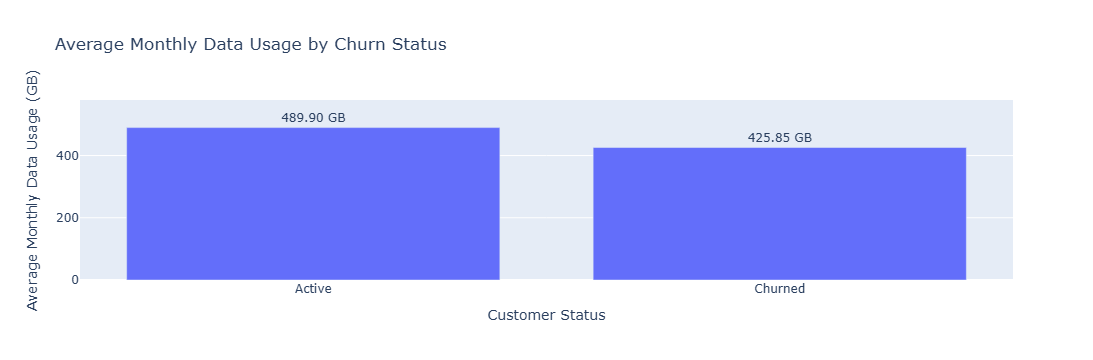

In [59]:
# Visualization
fig = px.bar(
    usage_churn,
    x="churn_status",
    y="average_monthly_usage_gb",
    title="Average Monthly Data Usage by Churn Status",
    text="average_monthly_usage_gb"
)

fig.update_layout(
    xaxis_title="Customer Status",
    yaxis_title="Average Monthly Data Usage (GB)"
)

fig.update_traces(
    texttemplate="%{text:.2f} GB",
    textposition="outside"
)

fig.show()

## Average Customer Usage by Churn Status Analysis

Churned customers had lower average monthly data usage than active customers throughout the analysis period. Active customers averaged 489.90 GB of monthly data usage, compared with 425.85 GB among churned customers.

This represents a difference of 64.05 GB per month, with churned customers using approximately 13% less data than active customers.

The result suggests that lower customer engagement is associated with increased churn. Customers with lower usage may represent a potential retention risk, as declining or consistently low usage could indicate reduced engagement with the service.

However, this analysis shows an association rather than causation. Lower usage may contribute to churn, but customers who are already considering leaving may also reduce their usage before churning.

Further analysis of usage levels can help determine whether churn risk increases progressively as customer usage decreases.

In [60]:
# SQL query
usage_churn_rate = pd.read_sql_query(
    """
    WITH customer_usage AS (
        SELECT
            customer_id,
            AVG(data_usage_gb) AS avg_monthly_usage_gb
        FROM monthly_usage
        GROUP BY customer_id
    ),

    usage_groups AS (
        SELECT
            customer_id,
            avg_monthly_usage_gb,
            CASE
                WHEN avg_monthly_usage_gb < 250
                    THEN 'Under 250 GB'
                WHEN avg_monthly_usage_gb < 500
                    THEN '250-500 GB'
                WHEN avg_monthly_usage_gb < 750
                    THEN '500-750 GB'
                ELSE '750+ GB'
            END AS usage_group
        FROM customer_usage
    )

    SELECT
        usage_groups.usage_group,
        COUNT(DISTINCT usage_groups.customer_id)
            AS total_customers,
        COUNT(
            DISTINCT CASE
                WHEN customer_churn.churned = 1
                    THEN usage_groups.customer_id
            END
        ) AS churned_customers,
        ROUND(
            100.0 * COUNT(
                DISTINCT CASE
                    WHEN customer_churn.churned = 1
                        THEN usage_groups.customer_id
                END
            )
            / COUNT(DISTINCT usage_groups.customer_id),
            2
        ) AS churn_rate
    FROM usage_groups
    LEFT JOIN customer_churn
        ON usage_groups.customer_id = customer_churn.customer_id
    GROUP BY
        usage_groups.usage_group
    ORDER BY
        CASE usage_groups.usage_group
            WHEN 'Under 250 GB' THEN 1
            WHEN '250-500 GB' THEN 2
            WHEN '500-750 GB' THEN 3
            WHEN '750+ GB' THEN 4
        END;
    """,
    conn
)

usage_churn_rate

,usage_group,total_customers,churned_customers,churn_rate
0,Under 250 GB,1971,312,15.83
1,250-500 GB,6565,874,13.31
2,500-750 GB,3144,278,8.84
3,750+ GB,1861,141,7.58


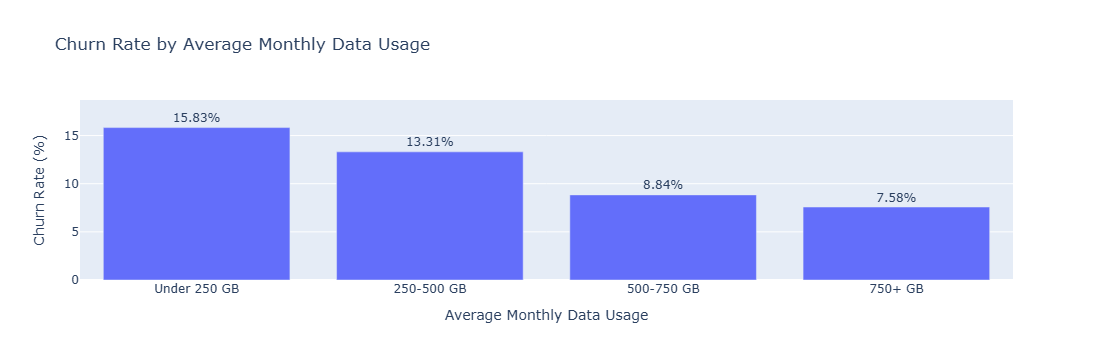

In [61]:
# Visualization
fig = px.bar(
    usage_churn_rate,
    x="usage_group",
    y="churn_rate",
    title="Churn Rate by Average Monthly Data Usage",
    text="churn_rate"
)

fig.update_layout(
    xaxis_title="Average Monthly Data Usage",
    yaxis_title="Churn Rate (%)"
)

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside"
)

fig.show()

## Churn Rate by Usage Level Analysis

Churn rate decreases consistently as average monthly data usage increases. Customers using under 250 GB per month had the highest churn rate at 15.83%, while customers using 750 GB or more had the lowest churn rate at 7.58%.

The relationship is relatively strong across the usage groups. Churn falls from 15.83% among the lowest-usage customers to 13.31% among customers using 250-500 GB, then declines further to 8.84% among customers using 500-750 GB and 7.58% among customers using 750 GB or more.

This suggests that lower customer engagement is associated with greater churn risk. Customers with consistently low data usage may be more likely to leave the service, making usage level a potentially useful indicator for identifying customers at higher risk of churn.

However, this analysis demonstrates an association rather than causation. Lower usage may contribute to churn, but customers who are already disengaging may also reduce their usage before churning. Other factors, such as subscription plan, contract type, and customer segment, may also influence both usage and churn.

Overall, usage level appears to be a stronger behavioral indicator of churn than demographic characteristics examined earlier, where churn rates varied relatively little between age groups.

## Usage Trends Before Churn

Previous analysis found that customers with lower average monthly data usage had higher churn rates.

This analysis examines whether customer usage changes in the months leading up to churn. By comparing usage relative to each customer's churn date, we can determine whether declining engagement may act as an early indicator of churn risk.

In [65]:
# SQL query
usage_before_churn = pd.read_sql_query(
    """
    SELECT
        (
            CAST(strftime('%Y', customer_churn.churn_date) AS INTEGER) * 12
            + CAST(strftime('%m', customer_churn.churn_date) AS INTEGER)
        )
        -
        (
            CAST(strftime('%Y', monthly_usage.usage_month) AS INTEGER) * 12
            + CAST(strftime('%m', monthly_usage.usage_month) AS INTEGER)
        ) AS months_until_churn,
        ROUND(
            AVG(monthly_usage.data_usage_gb),
            2
        ) AS average_monthly_data_usage_gb,
        COUNT(DISTINCT monthly_usage.customer_id)
            AS sample_size
    FROM monthly_usage
    INNER JOIN customer_churn
        ON monthly_usage.customer_id = customer_churn.customer_id
    WHERE customer_churn.churned = 1
        AND monthly_usage.usage_month <= customer_churn.churn_date
    GROUP BY
        months_until_churn
    HAVING months_until_churn BETWEEN 0 AND 5
    ORDER BY
        months_until_churn DESC;
    """,
    conn
)

usage_before_churn

,months_until_churn,average_monthly_data_usage_gb,sample_size
0,5,415.27,711
1,4,422.83,837
2,3,431.53,981
3,2,427.22,1162
4,1,421.56,1360
5,0,422.22,1605


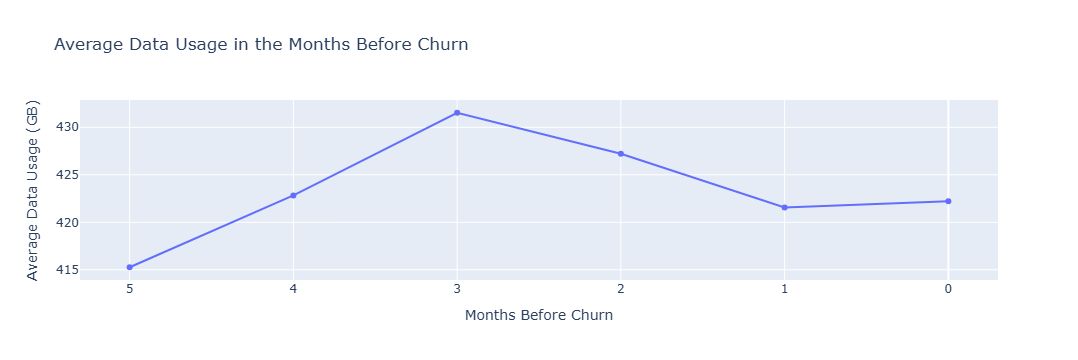

In [67]:
# Visualization
fig = px.line(
    usage_before_churn,
    x="months_until_churn",
    y="average_monthly_data_usage_gb",
    markers=True,
    title="Average Data Usage in the Months Before Churn"
)

fig.update_layout(
    xaxis_title="Months Before Churn",
    yaxis_title="Average Data Usage (GB)"
)

fig.update_xaxes(
    autorange="reversed",
    dtick=1
)

fig.show()

## Usage Trends Before Churn Analysis

Although lower overall data usage was associated with higher churn rates in the previous analysis, usage does not show a clear downward trend in the months immediately preceding churn.

Among customers who eventually churned, average monthly usage ranged from 415.27 GB to 431.53 GB during the five months before churn. Usage increased slightly from five to three months before churn before declining modestly, but remained relatively stable at approximately 420 GB through the churn month.

This suggests that while lower usage may be associated with higher overall churn risk, customers do not appear to progressively reduce their data usage immediately before churning. Therefore, declining usage does not appear to be a strong standalone early-warning indicator of churn in this dataset.

The sample size also increases as the analysis approaches the churn month because more customers have sufficient usage history to be included. The churn-month result is based on all 1,605 churned customers, while the five-month-before result is based on 711 customers.

## Churn Risk Profile

The preceding analysis examined several customer characteristics and behaviors in relation to churn. This section consolidates the strongest findings to identify customer groups with comparatively higher churn rates.

The goal is not to establish causation, but to identify patterns that may help the business prioritize customers and behaviors for further investigation and potential retention efforts.

In [68]:
# Creating a consolidated table of the strongest findings
risk_indicators = pd.DataFrame({
    "indicator": [
        "Contract Type",
        "Plan",
        "Support Ticket Volume",
        "Unresolved Tickets",
        "Usage Level",
        "Customer Segment"
    ],
    "category": [
        "Month-to-month",
        "Essential",
        "4+ Tickets",
        "Has Unresolved Ticket",
        "Under 250 GB",
        "Consumer"
    ],
    "churn_rate": [
        22.87,
        23.61,
        28.81,
        27.19,
        15.83,
        19.49
    ]
})

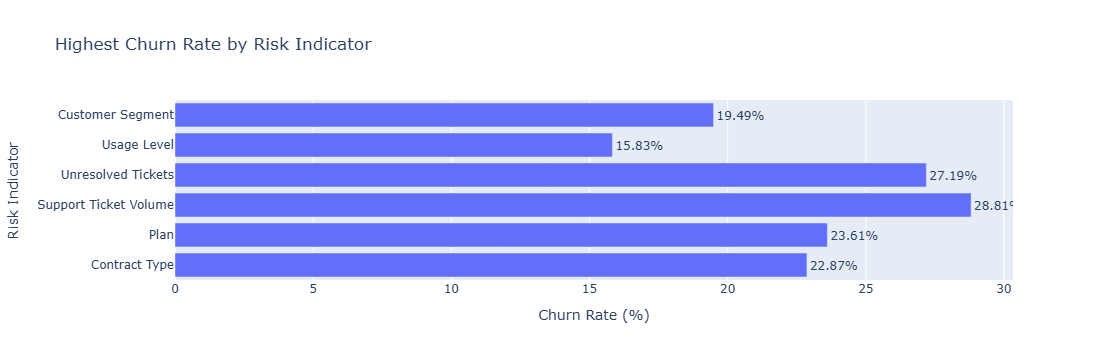

In [69]:
# Visualization
fig = px.bar(
    risk_indicators,
    x="churn_rate",
    y="indicator",
    orientation="h",
    text="churn_rate",
    hover_data=["category"],
    title="Highest Churn Rate by Risk Indicator"
)

fig.update_layout(
    xaxis_title="Churn Rate (%)",
    yaxis_title="Risk Indicator"
)

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside"
)

fig.show()

## Churn Risk Profile Analysis

Several customer characteristics are associated with substantially higher churn rates. Support-ticket volume shows the largest difference, with customers who submitted 4 or more tickets having a churn rate of 28.81%, compared with 16.84% among customers with no support tickets. Customers with unresolved support tickets also had elevated churn at 27.19%, suggesting that unresolved customer issues may be an important retention concern.

Contract type is another strong differentiator. Month-to-month customers had a churn rate of 22.87%, more than twice the 10.94% rate among customers on 2-year contracts. Subscription plan also showed meaningful variation, with Essential customers experiencing the highest plan-level churn rate at 23.61%.

Usage level showed a clear relationship with churn as well. Customers using under 250 GB per month had a churn rate of 15.83%, compared with 7.58% among customers using 750 GB or more. This supports the earlier finding that lower customer engagement is associated with higher churn, although the analysis of usage immediately before churn did not show a consistent decline in usage.

Customer segment and age showed smaller differences in comparison. Consumer customers had a churn rate of 19.49%, compared with 15.59% for Small Business customers, while churn rates across age groups ranged from 17.92% to 20.06%.

Overall, the strongest churn indicators identified in this analysis are support-related issues, contract type, subscription plan, and usage level. These findings provide a basis for prioritizing retention efforts, while recognizing that the analysis examines each factor individually and does not establish that any single factor causes churn.

## Executive Summary & Key Findings

The analysis examined customer growth, recurring revenue, customer engagement, support interactions, subscription characteristics, and churn behavior throughout 2025. The findings indicate that while the customer base and recurring revenue grew during the year, the rate of net customer growth declined as churn increased.

Several customer characteristics and behaviors were associated with elevated churn rates, with support issues, contract type, subscription plan, and usage level emerging as the strongest indicators. The following findings summarize the most important business insights from the analysis.

### 1. Customer and Revenue Growth Remained Positive, but Momentum Weakened

Monthly active customers increased steadily from 10,123 in January to 12,184 in December, while monthly recurring revenue increased from 767,646 to 928,729.75 over the same period. This indicates that the business continued to expand its customer base and recurring revenue throughout 2025.

However, net customer growth declined substantially during the year. Monthly customer additions remained relatively stable, generally ranging between approximately 285 and 361 new customers, while churn increased from 70 customers in January to 331 in December. As a result, monthly net customer growth fell from 291 customers in January to -11 in December.

This suggests that the overall growth trajectory became increasingly dependent on maintaining customer retention. Although the business ended the year with more customers and higher recurring revenue than it started with, the sharp increase in churn toward the end of the year represents a potential threat to future growth.

### 2. Month-to-Month Customers Have Substantially Higher Churn

Contract type was one of the strongest differences observed in the analysis. Month-to-month customers had a churn rate of 22.87%, compared with only 10.94% among customers on 2-year contracts.

The difference was consistent across both customer segments. Consumer customers had churn rates of 22.68% for month-to-month contracts and 10.91% for 2-year contracts, while Small Business customers had rates of 25.32% and 11.00%, respectively.

This suggests that contract structure is strongly associated with retention. The business may benefit from understanding why month-to-month customers are more likely to leave and whether incentives or targeted offers could encourage longer-term commitments.

### 3. Customers Experiencing Support Issues Have Higher Churn

Support-related behavior showed a strong relationship with churn. Customers who submitted 4 or more support tickets had a churn rate of 28.81%, compared with 16.84% among customers who submitted no tickets.

Unresolved issues were also associated with higher churn. Customers with an unresolved support ticket had a churn rate of 27.19%, compared with 18.41% among customers with no unresolved tickets.

These results suggest that repeated or unresolved customer issues may represent an important retention risk. While the analysis does not establish that support problems cause churn, customers experiencing significant support friction appear to warrant additional attention from retention and customer-support teams.

### 4. Lower Customer Usage Is Associated with Higher Churn

Customer engagement also showed a clear relationship with churn. Customers using under 250 GB of data per month had a churn rate of 15.83%, compared with 7.58% among customers using 750 GB or more.

The relationship was consistent across the usage groups, with churn decreasing as average monthly usage increased. This suggests that lower engagement may be a useful indicator when identifying customers who could be at elevated risk of churn.

However, an analysis of usage during the months leading up to churn did not show a consistent decline in usage. Average usage remained relatively stable at approximately 420 GB among customers who eventually churned. Therefore, low usage appears to be associated with churn at the customer level, but declining usage immediately before churn does not appear to be a strong early-warning signal in this dataset.

### 5. Plan and Customer Segment Differences Provide Additional Context

Churn varied considerably across subscription plans. Essential customers had the highest churn rate at 23.61%, followed by Standard customers at 22.62%. In contrast, Business Pro, Premium, and Ultra customers had churn rates between 11.60% and 12.53%.

Customer segment differences were smaller. Consumer customers had a churn rate of 19.49%, compared with 15.59% for Small Business customers. Age also showed relatively limited variation, with churn rates ranging from 17.92% to 20.06%.

These results suggest that subscription characteristics and customer behavior provide more useful signals for understanding churn than demographic characteristics such as age.

## Business Recommendations

The analysis identifies several areas where the business could focus retention efforts. Because the relationships observed in this analysis represent associations rather than proven causes of churn, these recommendations should be treated as targeted areas for investigation and intervention rather than definitive solutions.

### 1. Prioritize Retention Efforts for Month-to-Month Customers

Month-to-month customers had a churn rate of 22.87%, compared with 10.94% for customers on 2-year contracts. The business should investigate whether targeted incentives, loyalty benefits, or contract conversion offers could encourage month-to-month customers to move toward longer-term commitments.

Retention efforts should be particularly targeted rather than applied uniformly, since combining contract type with other risk indicators may help identify customers most likely to benefit from intervention.

### 2. Prioritize Customers Experiencing Repeated or Unresolved Support Issues

Customers with 4 or more support tickets had a churn rate of 28.81%, while customers with unresolved tickets had a churn rate of 27.19%. These were among the highest churn rates identified in the analysis.

The business should consider monitoring customers with repeated or unresolved support interactions and creating an escalation process for high-risk cases. Resolving persistent issues before they result in cancellation could improve customer retention and provide a measurable opportunity for the support team to contribute to retention efforts.

### 3. Investigate Low-Usage Customers as a Potential Retention Segment

Customers using under 250 GB per month had a churn rate of 15.83%, compared with 7.58% among customers using 750 GB or more.

The business could monitor low-usage customers for signs of disengagement and investigate whether targeted engagement initiatives could increase service adoption. However, because usage did not consistently decline in the months immediately preceding churn, low usage should be treated as a broader risk indicator rather than a reliable short-term churn warning.

### 4. Investigate High-Churn Subscription Plans

Essential and Standard customers had substantially higher churn rates than the other subscription plans, at 23.61% and 22.62%, respectively.

The business should investigate whether these customers experience differences in pricing, features, perceived value, service quality, or customer expectations that could explain the higher churn. Understanding these differences could help determine whether changes to plan features, pricing, or retention strategies are warranted.

### 5. Monitor the Decline in Net Customer Growth

Although active customers and MRR increased throughout 2025, net customer growth deteriorated from 291 new customers in January to -11 in December. This was driven primarily by the sharp increase in monthly churn while customer acquisition remained relatively stable.

This trend should be monitored as an executive-level KPI. Continued growth in churn could eventually reverse the positive trajectory observed in active customers and recurring revenue, making retention increasingly important to sustaining future growth.

### 6. Develop a Combined Churn-Risk Monitoring Approach

The strongest indicators identified in the analysis were contract type, support interactions, usage level, and subscription plan. Rather than evaluating these characteristics independently, the business could combine them into a customer-level risk framework.

For example, a month-to-month customer with low usage and an unresolved support issue may warrant more immediate attention than a customer exhibiting only one of these characteristics.

A future iteration of the analysis could develop a formal churn-risk score using historical customer behavior and evaluate how accurately it identifies customers who subsequently churn.

## Conclusion

This analysis examined customer growth, recurring revenue, customer engagement, support interactions, subscription characteristics, and churn behavior throughout 2025.

The business experienced positive growth in both active customers and monthly recurring revenue during the year. However, declining net customer growth and a sharp increase in churn toward the end of the year indicate that customer retention is becoming an increasingly important business concern.

Several factors were strongly associated with churn. Month-to-month customers had substantially higher churn than customers on 2-year contracts, while customers experiencing repeated or unresolved support issues also showed elevated churn. Lower average data usage was associated with higher churn, although customers did not show a consistent decline in usage immediately before churning. Subscription plan also showed meaningful differences in churn, particularly among Essential and Standard customers.

Overall, the analysis suggests that the greatest opportunities for improving retention may come from focusing on customers with multiple risk indicators rather than relying on any single characteristic. Combining contract type, support interactions, usage, and subscription plan could provide a stronger foundation for identifying customers who may benefit from proactive retention efforts.

The findings provide a starting point for further investigation and the development of a more formal churn prediction or customer-risk model. Such a model could help the business move from understanding historical churn patterns toward identifying at-risk customers early enough to take action.